# Master Thesis - Vignoli Lorenzo

---

## 🐙 Helyx testing

## ⚙️ Import Libraries

In [ ]:
# Libraries
import os
import glob
import random
import warnings
import numpy as np # type: ignore
from sklearn.model_selection import train_test_split # type: ignore

import torch # type: ignore
import torch.nn as nn # type: ignore
import torch.optim as optim # type: ignore
from torch.utils.data import Dataset, DataLoader, RandomSampler # type: ignore
import torch.nn.functional as F # type: ignore
import shutil
import plotly.graph_objects as go # type: ignore
from torch.optim.lr_scheduler import LinearLR, ReduceLROnPlateau # type: ignore
import torchvision.transforms as T
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
import matplotlib as mpl # type: ignore
from matplotlib import rcParams # type: ignore
from cycler import cycler # type: ignore
import pandas as pd # type: ignore
import random
import sys
from torch.amp import GradScaler, autocast # type: ignore
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from scipy.spatial.transform import Rotation as R
from scipy.linalg import solve
from numpy.linalg import lstsq
from scipy.linalg import null_space
import torchvision.models as models
from torchvision.models import mobilenet_v2
from scipy.integrate import cumulative_trapezoid
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
from tqdm import tqdm # type: ignore

# Reconstruction utility
from MULTI_reconstruction_utility import *

# PCC model
from MULTI_jacobians import *
from MULTI_kinematics import *

# Publication-ready plotting setup with TRUE LaTeX rendering
rcParams.update({
   'figure.figsize': (6, 4), 'figure.dpi': 300, 'savefig.dpi': 300,
   'savefig.format': 'pdf', 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1,
   'font.family': 'serif', 'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
   'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10,
   'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
   'lines.linewidth': 1.5, 'lines.markersize': 6, 'lines.markeredgewidth': 0.5,
   'axes.linewidth': 1.0, 'axes.spines.top': False, 'axes.spines.right': False,
   'axes.grid': True, 'axes.edgecolor': 'black',
   'xtick.direction': 'in', 'ytick.direction': 'in',
   'xtick.major.size': 4, 'ytick.major.size': 4,
   'xtick.minor.size': 2, 'ytick.minor.size': 2,
   'xtick.minor.visible': True, 'ytick.minor.visible': True,
   'grid.color': 'gray', 'grid.linestyle': '-', 'grid.linewidth': 0.5, 'grid.alpha': 0.3,
   'legend.frameon': True, 'legend.framealpha': 0.9, 'legend.fancybox': False,
   'legend.edgecolor': 'black', 'legend.facecolor': 'white', 'legend.numpoints': 1,
   'text.usetex': True,  # TRUE LaTeX rendering
   'mathtext.default': 'regular',
   'axes.unicode_minus': False,
   'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'
})

sns.set_style("whitegrid", {"axes.spines.left": True, "axes.spines.bottom": True,
                          "axes.spines.top": False, "axes.spines.right": False,
                          "grid.color": "0.8", "grid.linestyle": "-", "grid.linewidth": 0.5})

# Professional color palette
pub_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
             '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(pub_colors)
rcParams['axes.prop_cycle'] = cycler('color', pub_colors)

# Ignore warnings
warnings.filterwarnings("ignore")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("True LaTeX rendering enabled for all plots")   # debugging

Using device: cuda
True LaTeX rendering enabled for all plots


Angular metric

In [2]:
def AngularDistance(pred_euler, target_euler):
        """
        Computes angular distance given predicted and target euler angles ('zyx').
        This is done according to the rotation along the principal axis.
        """

        r_pred = R.from_euler('zyx', pred_euler) 
        r_target = R.from_euler('zyx', target_euler)
        r_error = r_target * r_pred.inv()
        axis_angle = r_error.as_rotvec()
        return np.linalg.norm(axis_angle)

def AngError(pred_euler, target_euler):
    """
    Computes angular error given predicted and target euler angles ('zyx').
    This is done reporting it between 0 and 180 degrees.
    """
    diff = target_euler - pred_euler
    
    # Wrap each angle difference to [-180, 180] then take absolute value
    wrapped = ((diff + 180) % 360) - 180
    
    return np.abs(wrapped)

## ⏳ Load and process the Data

Plot random image from datasets for data acquisition correctness

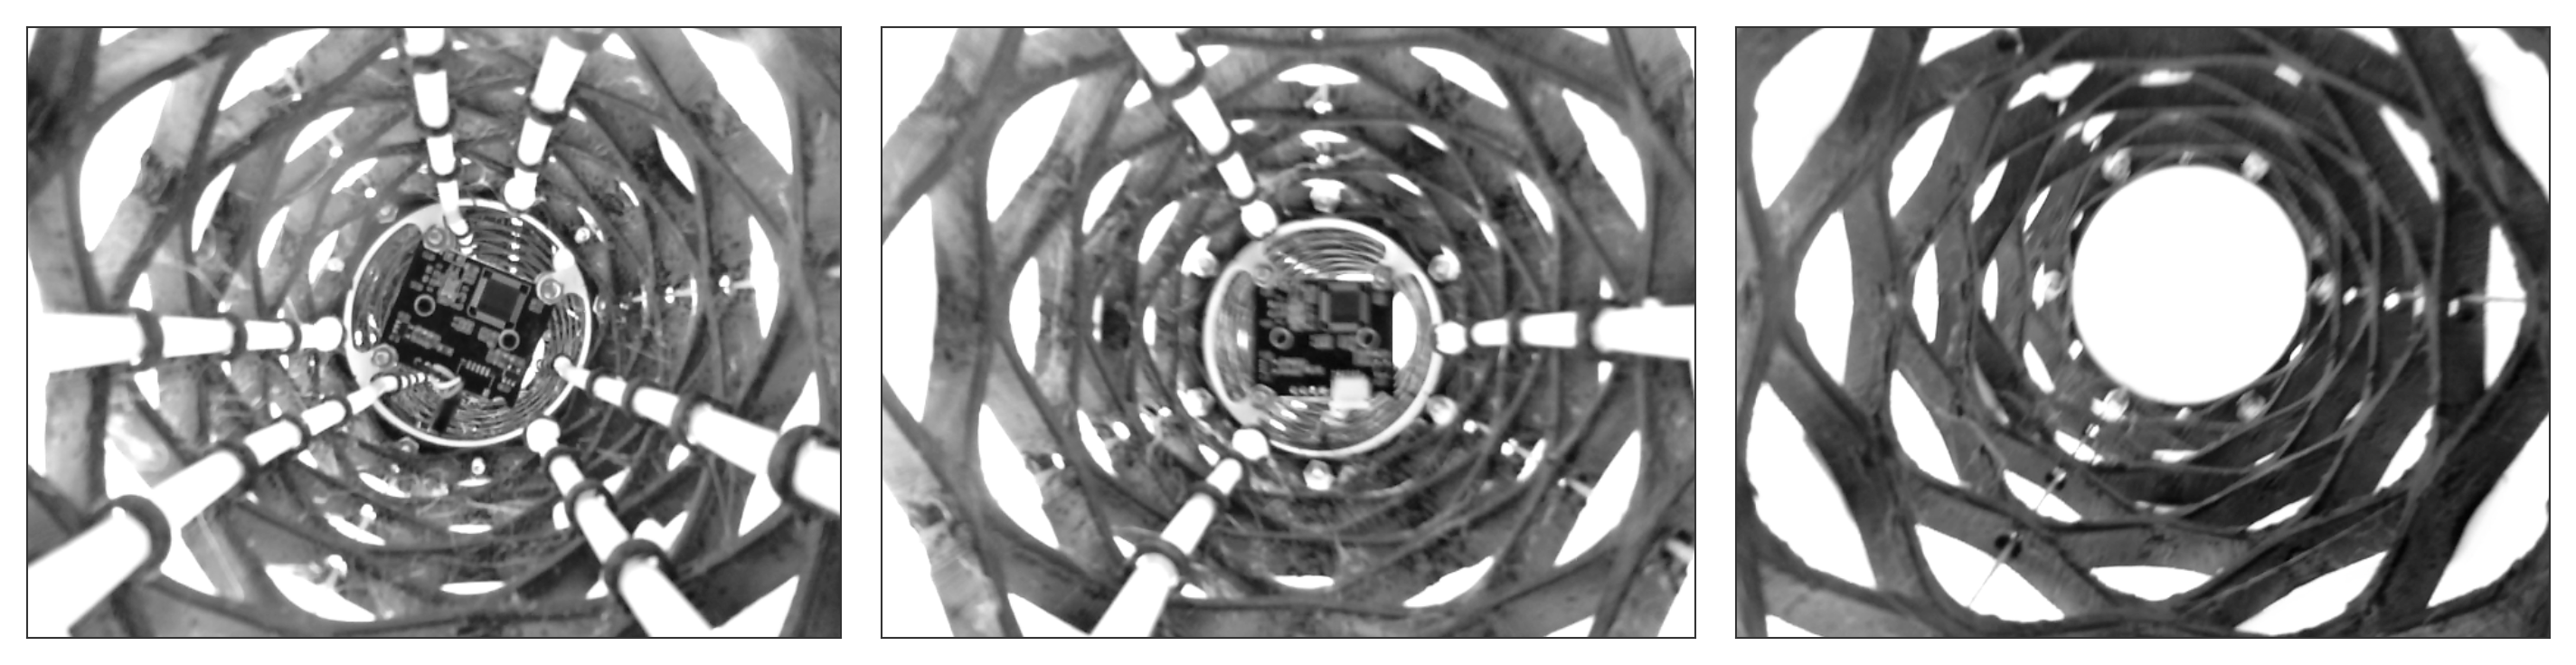

In [3]:
def plot_random_image():
    dataset_files = glob.glob("DatasetMulti*.pt")
    
    if not dataset_files:
        return
    
    random_file = random.choice(dataset_files)
    data_dict = torch.load(random_file)
    X_images = data_dict["X_images"]
    
    if isinstance(X_images, list):
        X_images = torch.stack(X_images)
    
    num_samples = X_images.shape[0]
    random_idx = random.randint(0, num_samples - 1)
    
    image_tensor = X_images[random_idx]
    image_np = image_tensor.permute(1, 2, 0).numpy()
    
    # Enhanced publication-ready visualization
    fig = plt.figure(figsize=(12, 4))
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.05, hspace=0.02)
    
    for i in range(3):
        ax = fig.add_subplot(gs[0, i])
        
        # Enhanced image display with proper normalization
        img_normalized = (image_np[:, :, i] - image_np[:, :, i].min()) / \
                        (image_np[:, :, i].max() - image_np[:, :, i].min())
        
        im = ax.imshow(img_normalized, cmap='gray', aspect='equal', 
                       interpolation='bilinear', vmin=0, vmax=1)
        
        ax.set_xlim(0, image_np.shape[1])
        ax.set_ylim(image_np.shape[0], 0)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)
        
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
            spine.set_color('#333333')
    
    plt.savefig('multi_camera_view.pdf', dpi=300, bbox_inches='tight', 
                pad_inches=0.02, facecolor='white', edgecolor='none')
    plt.show()

for _ in range(1):
    plot_random_image()

Data processing

In [4]:
def save_tensor_as_png(tensor, path):
   """
   Save tensor as PNG image.
   """
   if tensor.dtype != torch.uint8:
       tensor = tensor.to(torch.uint8)
   
   # Convert from CHW to HWC for PIL
   if len(tensor.shape) == 3:
       tensor = tensor.permute(1, 2, 0)
   
   # Convert to numpy and save
   image_np = tensor.numpy()
   image = Image.fromarray(image_np)
   image.save(path)

In [5]:
if False:

    for split in ["train", "val", "test"]:
        shutil.rmtree(f"images_multi/{split}", ignore_errors=True)
        shutil.rmtree(f"tip1/{split}", ignore_errors=True)
        shutil.rmtree(f"tip2/{split}", ignore_errors=True)
        shutil.rmtree(f"tip3/{split}", ignore_errors=True)
        shutil.rmtree(f"quad/{split}", ignore_errors=True)
        shutil.rmtree(f"affine/{split}", ignore_errors=True)
        shutil.rmtree(f"const/{split}", ignore_errors=True)
        shutil.rmtree(f"DELTAL_sensing", ignore_errors=True)
        os.makedirs(f"images_multi/{split}", exist_ok=True)
        os.makedirs(f"tip1/{split}", exist_ok=True)
        os.makedirs(f"tip2/{split}", exist_ok=True)
        os.makedirs(f"tip3/{split}", exist_ok=True)
        os.makedirs(f"quad/{split}", exist_ok=True)
        os.makedirs(f"affine/{split}", exist_ok=True)
        os.makedirs(f"const/{split}", exist_ok=True)
        os.makedirs(f"DELTAL_sensing", exist_ok=True)

    dataset_files = sorted(glob.glob("DatasetMulti*.pt"))
    total_originals = sum([len(torch.load(f)["X_images"]) for f in dataset_files])
    all_indices = np.arange(total_originals)

    train_idx, temp_idx = train_test_split(all_indices, test_size=0.15)
    val_idx, test_idx = train_test_split(temp_idx, test_size=1/3)

    split_map = np.full(total_originals, "", dtype=object)
    split_map[train_idx] = "train"
    split_map[val_idx] = "val"
    split_map[test_idx] = "test"

    global_index = {
        "train": 0,
        "val": 0,
        "test": 0
    }

    current_idx = 0

    for file in dataset_files:

        # Process each dataset file
        print(f"\n Processing {file}...")
        data = torch.load(file)
        X_images = data["X_images"]
        X_quad = data["X_quad"]
        X_affine = data["X_affine"]
        X_const = data["X_const"]
        DELTAL = data["X_DELTAL"]
        tip_1 = data["tip_1"]
        tip_2 = data["tip_2"]
        tip_3 = data["tip_3"]
        print(f"mean tip_1[2]: {torch.stack(tip_1)[:, 2].float().mean():.4f}, "
                f"mean tip_2[2]: {torch.stack(tip_2)[:, 2].float().mean():.4f}, "
                f"mean tip_3[2]: {torch.stack(tip_3)[:, 2].float().mean():.4f}")

        for i in range(len(X_images)):

            split = split_map[current_idx]
            idx_str = f"{global_index[split]:06d}"

            # Save images as PNG
            save_tensor_as_png(X_images[i], f"images_multi/{split}/img_{idx_str}.png")
           
            # Save all labels as PT
            torch.save(tip_1[i], f"tip1/{split}/tip1_{idx_str}.pt")
            torch.save(tip_2[i], f"tip2/{split}/tip2_{idx_str}.pt")
            torch.save(tip_3[i], f"tip3/{split}/tip3_{idx_str}.pt")
            torch.save(X_quad[i], f"quad/{split}/quad_{idx_str}.pt")
            torch.save(X_affine[i], f"affine/{split}/affine_{idx_str}.pt")
            torch.save(X_const[i], f"const/{split}/const_{idx_str}.pt")
            torch.save(DELTAL[i], f"DELTAL_sensing/DELTAL_{idx_str}.pt")

            global_index[split] += 1
            current_idx += 1

            percent = (current_idx / total_originals) * 100
            sys.stdout.write(f"\rProgress: {percent:.2f}%")
            sys.stdout.flush()

        del X_images, X_quad, X_affine, X_const, tip_1, tip_2, tip_3, DELTAL

    print(f"\nFinished dataset generation, with {total_originals} total samples.")


In [6]:
if False:

   for split in ["train", "val", "test"]:
       shutil.rmtree(f"end_effector/{split}", ignore_errors=True)
       shutil.rmtree(f"DELTAL/{split}", ignore_errors=True)
       os.makedirs(f"end_effector/{split}", exist_ok=True)
       os.makedirs(f"DELTAL/{split}", exist_ok=True)

   dataset_files = sorted(glob.glob("FKdata*.pt"))
   total_originals = sum([len(torch.load(f)["DELTAL"]) for f in dataset_files])
   all_indices = np.arange(total_originals)

   train_idx, temp_idx = train_test_split(all_indices, test_size=0.15)
   val_idx, test_idx = train_test_split(temp_idx, test_size=1/3)

   split_map = np.full(total_originals, "", dtype=object)
   split_map[train_idx] = "train"
   split_map[val_idx] = "val"
   split_map[test_idx] = "test"

   global_index = {
       "train": 0,
       "val": 0,
       "test": 0
   }

   current_idx = 0

   for file in dataset_files:

       # Process each dataset file
       print(f"\n Processing {file}...")
       data = torch.load(file)
       X_DELTAL = data["DELTAL"]
       end_effector = data["tip3_pose"]

       for i in range(len(X_DELTAL)):

           split = split_map[current_idx]
           idx_str = f"{global_index[split]:06d}"
           
           # Save all labels as PT
           torch.save(X_DELTAL[i], f"DELTAL/{split}/deltal_{idx_str}.pt")
           torch.save(end_effector[i], f"end_effector/{split}/end_effector_{idx_str}.pt")

           global_index[split] += 1
           current_idx += 1

           percent = (current_idx / total_originals) * 100
           sys.stdout.write(f"\rProgress: {percent:.2f}%")
           sys.stdout.flush()

   print(f"\nFinished dataset generation, with {total_originals} total samples.")


## ⏳ Dataset generation

In [7]:
# Save summary statistics for normalization
if False:
    # --- tip1 (target position + orientation) ---
    tip1_paths = sorted(glob.glob("tip1/train/*.pt"))
    all_tip1 = torch.stack([torch.load(p).float() for p in tip1_paths])
    mean_tip1 = all_tip1.mean(dim=0)
    std_tip1 = all_tip1.std(dim=0)
    torch.save({'mean': mean_tip1, 'std': std_tip1}, 'tip1_stats.pt')
    del all_tip1, mean_tip1, std_tip1

    # --- tip2 (target position + orientation) ---
    tip2_paths = sorted(glob.glob("tip2/train/*.pt"))
    all_tip2 = torch.stack([torch.load(p).float() for p in tip2_paths])
    mean_tip2 = all_tip2.mean(dim=0)
    std_tip2 = all_tip2.std(dim=0)
    torch.save({'mean': mean_tip2, 'std': std_tip2}, 'tip2_stats.pt')
    del all_tip2, mean_tip2, std_tip2

    # --- tip3 (target position + orientation) ---
    tip3_paths = sorted(glob.glob("tip3/train/*.pt"))
    all_tip3 = torch.stack([torch.load(p).float() for p in tip3_paths])
    mean_tip3 = all_tip3.mean(dim=0)
    std_tip3 = all_tip3.std(dim=0)
    torch.save({'mean': mean_tip3, 'std': std_tip3}, 'tip3_stats.pt')
    del all_tip3, mean_tip3, std_tip3

    # --- quad (shape descriptors) ---
    backbone_paths = sorted(glob.glob("quad/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'quad_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- affine (shape descriptors) ---
    backbone_paths = sorted(glob.glob("affine/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'affine_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- const (shape descriptors) ---
    backbone_paths = sorted(glob.glob("const/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'const_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- inverse kinematics ---
    DELTAL_paths = sorted(glob.glob("DELTAL_sensing/*.pt"))
    all_DELTAL = torch.stack([torch.load(p).float() for p in DELTAL_paths])
    mean = all_DELTAL.mean(dim=0)
    std = all_DELTAL.std(dim=0)
    torch.save({'mean': mean, 'std':std}, 'models/kinematics/DELTAL_stats.pt')
    del all_DELTAL, mean, std

    # --- end effector (position + orientation) ---
    end_effector_paths = sorted(glob.glob("end_effector/train/*.pt"))
    all_end_effector = torch.stack([torch.load(p).float() for p in end_effector_paths])
    mean_end_effector = all_end_effector.mean(dim=0)
    std_end_effector = all_end_effector.std(dim=0)
    torch.save({'mean': mean_end_effector, 'std': std_end_effector}, 'end_effector_stats.pt')
    del all_end_effector, mean_end_effector, std_end_effector

Definition of the Workspace in terms of tip1, tip2, tip3, pose

In [8]:
# Collect all tip files to define the workspace
tips = [
    ("tip1/*/tip1_*.pt", []),
    ("tip2/*/tip2_*.pt", []),
    ("tip3/*/tip3_*.pt", [])
]

pose_list = []

for i, (pattern, pos_list) in enumerate(tips):
    files = sorted(glob.glob(pattern))
    for f in files:
        label = torch.load(f)[:3]
        pos_list.append(label.numpy())
        
        # Only collect full pose for tip3 (6D: xyz + yaw,pitch,roll)
        if i == 2:  # tip3 index
            label_pose = torch.load(f)
            pose_list.append(label_pose.numpy())

# Assign to original variables
pos_tip1, pos_tip2, pos_tip3 = [pos for _, pos in tips]

# Define matrices: (N, 3) for positions, (N, 6) for poses
tip1_matrix = np.stack(pos_tip1)
tip2_matrix = np.stack(pos_tip2)
tip3_matrix = np.stack(pos_tip3)
pose_matrix = np.stack(pose_list)  # Shape: (N, 6)

# Save in .npz format
np.savez_compressed("Workspace.npz", tip1=tip1_matrix,
                                     tip2=tip2_matrix,
                                     tip3=tip3_matrix,
                                     pose=pose_matrix)
print(f"Workspace density: {tip1_matrix.shape}")

# Load the workspace from file
data = np.load("Workspace.npz")
x1 = data["tip1"]
x2 = data["tip2"]
x3 = data["tip3"]
pose = data["pose"]

# Example access
print("Point 5:")
print(x1[5])
print(x2[5])
print(x3[5])
print(pose[5])

del data, x1, x2, x3, pose, pos_tip1, pos_tip2, pos_tip3, tip1_matrix, tip2_matrix, tip3_matrix, pose_list, pose_matrix

Workspace density: (10000, 3)
Point 5:
[-27.92091     7.8175216 133.17677  ]
[-90.40476   27.012371 252.12053 ]
[-167.59491    38.119114  355.47885 ]
[-1.6759491e+02  3.8119114e+01  3.5547885e+02  1.5763106e-02
 -6.2389147e-01 -1.1918523e-01]


## ⏳ Dataset generation

Models to be tested:
1. CNN to reconstruct overall tips position
2. CNNs to reconstruct curvature (for the three approximations)
3. ANN for inverse kinematics (from 3 xyz to DELTAL)
4. ANN selector:
    - define xyz of each section based on the pose
    - use the trained network to test it

In [9]:
# Image regression, valid for both pose and reconstruction
class ImageRegressionDataset(Dataset):
   """
   Creates dataset with image paths (strings) and label
   paths (list of strings).
   """
   
   def __init__(self, image_paths, label_paths, split="train"):
       self.image_paths = image_paths
       if isinstance(label_paths[0], str):
           self.label_paths = [label_paths]  # if a string, wraps in a list
       else:
           self.label_paths = label_paths    # already list
       self.augment = split == "train"

   def __len__(self):
       return len(self.image_paths)

   def load_image(self, path):
       """Load PNG image and convert to tensor format (C, H, W)"""
       image = Image.open(path).convert('RGB')
       image = TF.to_tensor(image)  # converts to [0,1] float
       image = (image * 255).to(torch.uint8)  # convert to [0,255] uint8
       return image

   def apply_blur(self, image, kernel_size=5, sigma_max=8.0):
       sigma = random.uniform(0.0, sigma_max)
       image = image.float().unsqueeze(0) / 255.0
       image = TF.gaussian_blur(image, kernel_size=kernel_size, sigma=sigma)
       return (image.squeeze(0) * 255.0).clamp(0, 255).to(torch.uint8)

   def add_gaussian_noise(self, image, std_max=30.0):
       std = random.uniform(0.0, std_max)
       noise = torch.randn_like(image.float()) * std
       image = image.float() + noise
       return image.clamp(0, 255).to(torch.uint8)

   def apply_color_jitter(self, image, brightness=0.4, contrast=0.4):
       image = image.float().unsqueeze(0) / 255.0
       b = 1.0 + random.uniform(-brightness, brightness)
       c = 1.0 + random.uniform(-contrast, contrast)
       image = TF.adjust_brightness(image, b)
       image = TF.adjust_contrast(image, c)
       return (image.squeeze(0) * 255.0).clamp(0, 255).to(torch.uint8)

   def apply_brightness_shift(self, image, offset_max=0.3):
       offset = random.choice([-offset_max, offset_max])
       image = (image.float() / 255.0 + offset).clamp(0.0, 1.0)
       return (image * 255.0).to(torch.uint8)

   def apply_vignette(self, image, strength_max=0.6):
       strength = strength_max
       H, W = image.shape[1:]
       Y, X = torch.meshgrid(torch.linspace(-1, 1, H), torch.linspace(-1, 1, W), indexing='ij')
       radius = torch.sqrt(X**2 + Y**2)
       mask = 1.0 - strength * radius**2
       mask = mask.clamp(0.75, 1.0).unsqueeze(0)
       image = (image.float() / 255.0 * mask).clamp(0.0, 1.0)
       return (image * 255.0).to(torch.uint8)
   
   def apply_cutout(self, image, num_patches_range=(1, 3), max_ratio=0.5):
       C, H, W = image.shape
       num_patches = random.randint(*num_patches_range)
       for _ in range(num_patches):
           patch_h = int(random.uniform(0.0, max_ratio) * H)
           patch_w = int(random.uniform(0.0, max_ratio) * W)
           if patch_h == 0 or patch_w == 0:
               continue
           top = random.randint(0, H - patch_h)
           left = random.randint(0, W - patch_w)
           image[:, top:top + patch_h, left:left + patch_w] = 0  # black patch
       return image

   def __getitem__(self, idx):
       image = self.load_image(self.image_paths[idx])
       labels = [torch.load(paths[idx]).float().view(-1) for paths in self.label_paths]
       label = torch.cat(labels, dim=0)

       if self.augment:
           image = self.apply_blur(image)
           image = self.add_gaussian_noise(image)
           image = self.apply_color_jitter(image)
           image = self.apply_brightness_shift(image)
           image = self.apply_vignette(image)
           image = self.apply_cutout(image)

       label = label.view(-1)

       return image, label
   
# Generic path loader for images and target
def get_paths(split, target_folders):
   """
   Gets path for images and labels, and restitutes:
   - Image for single path
   - Label for a list, in case there are more
   """

   image_dir = os.path.join("images_multi", split)

   image_paths = sorted([
       os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(".png")
   ])

   if isinstance(target_folders, str):
       target_folders = [target_folders]   # case of single target, wraps in list (curvature)

   label_paths = []
   for folder in target_folders:
       target_dir = os.path.join(folder, split)
       paths = sorted([
           os.path.join(target_dir, f) for f in os.listdir(target_dir) if f.endswith(".pt")
       ])
       assert len(image_paths) == len(paths), f"Mismatch in {split} set for {folder}"
       label_paths.append(paths)

   return image_paths, label_paths


In [10]:
# Forward kinematics, valid from DELTAL to p
class FKDataset(Dataset):
    """
    Creates dataset for forward kinematics.
    """
    
    def __init__(self, input_paths, label_paths):
        self.input_paths = input_paths
        self.label_paths = label_paths

    def __len__(self):
        return len(self.label_paths)
    
    def __getitem__(self, idx):
        input_tensor = torch.load(self.input_paths[idx]).float()
        label_tensor = torch.load(self.label_paths[idx]).float()
        return input_tensor, label_tensor
    
def get_paths_FK(split):
    """
    Gets path for inputs and labels, and restitutes:
    - Input paths (DELTAL)
    - Label paths (end_effector)
    """

    label_dir = os.path.join("end_effector", split)
    label_paths = sorted([os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith(".pt")])
    input_dir = os.path.join("DELTAL", split)
    input_paths = sorted([os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith(".pt")])
    return input_paths, label_paths


In [11]:
# === First stage: training on tip pose ===
train_img_y, train_lbl_y = get_paths("train", ["tip1", "tip2", "tip3"])
val_img_y, val_lbl_y = get_paths("val", ["tip1", "tip2", "tip3"])
test_img_y, test_lbl_y = get_paths("test", ["tip1", "tip2", "tip3"])

train_dataset_y = ImageRegressionDataset(train_img_y, train_lbl_y, split="train")
val_dataset_y = ImageRegressionDataset(val_img_y, val_lbl_y, split="val")
test_dataset_y = ImageRegressionDataset(test_img_y, test_lbl_y, split="test")

# Shared sampler
shared_sampler = RandomSampler(train_dataset_y)

train_loader_y = DataLoader(train_dataset_y, batch_size=16, sampler=shared_sampler,
                            num_workers=12, pin_memory=True, persistent_workers=True)
val_loader_y = DataLoader(val_dataset_y, batch_size=16, shuffle=False,
                          num_workers=12, pin_memory=True, persistent_workers=True)
test_loader_y = DataLoader(test_dataset_y, batch_size=16, shuffle=False,
                           num_workers=12, pin_memory=True, persistent_workers=True)

# === Second stage: training on shape descriptors ===
target_folders = ["quad", "affine", "const"]
curvature_loaders = {}

# To use it, e.g. curvature_loaders["quad"]["train"], for all target folders
for target in target_folders:
    train_img, train_lbl = get_paths("train", target)
    val_img, val_lbl = get_paths("val", target)
    test_img, test_lbl = get_paths("test", target)

    train_ds = ImageRegressionDataset(train_img, train_lbl, split="train")
    val_ds = ImageRegressionDataset(val_img, val_lbl, split="val")
    test_ds = ImageRegressionDataset(test_img, test_lbl, split="test")

    train_loader = DataLoader(train_ds, batch_size=16, sampler=shared_sampler,
                              num_workers=12, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False,
                            num_workers=12, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False,
                             num_workers=12, pin_memory=True, persistent_workers=True)

    curvature_loaders[target] = {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader
    }

del train_loader, val_loader, test_loader

# === Third stage: forward kinematics ===
train_inputs, train_labels = get_paths_FK("train")
val_inputs, val_labels = get_paths_FK("val")
test_inputs, test_labels = get_paths_FK("test")

train_dataset = FKDataset(train_inputs, train_labels)
val_dataset = FKDataset(val_inputs, val_labels)
test_dataset = FKDataset(test_inputs, test_labels)

train_loader_FK = DataLoader(train_dataset, batch_size=64, shuffle=True,
                         num_workers=12, pin_memory=True, persistent_workers=True)
val_loader_FK = DataLoader(val_dataset, batch_size=64, shuffle=False,
                       num_workers=12, pin_memory=True, persistent_workers=True)
test_loader_FK = DataLoader(test_dataset, batch_size=64, shuffle=False,
                        num_workers=12, pin_memory=True, persistent_workers=True)

In [12]:
# Model for denormalization
class DenormalizedModel(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        out = self.base_model(x)
        return out * self.std + self.mean

# Model for 3 grayscale images CNN regression 
class NetCameraBW3x(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained MobileNetV2
        mobilenet = models.mobilenet_v2(pretrained=True)

        # Backbone: use directly the convolutional part
        self.backbone = mobilenet.features      # [B, 1280, H/32, W/32]
        self.pool = nn.AdaptiveAvgPool2d(1)     # [B, 1280, 1, 1]

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 18)
        )

    def forward(self, x):
        x = x / 255.0   # normalization from [0, 255] → [0, 1]

        x = self.backbone(x)
        x = self.pool(x)

        return self.head(x)

## ⏰ 0. Plotting workspace and random images

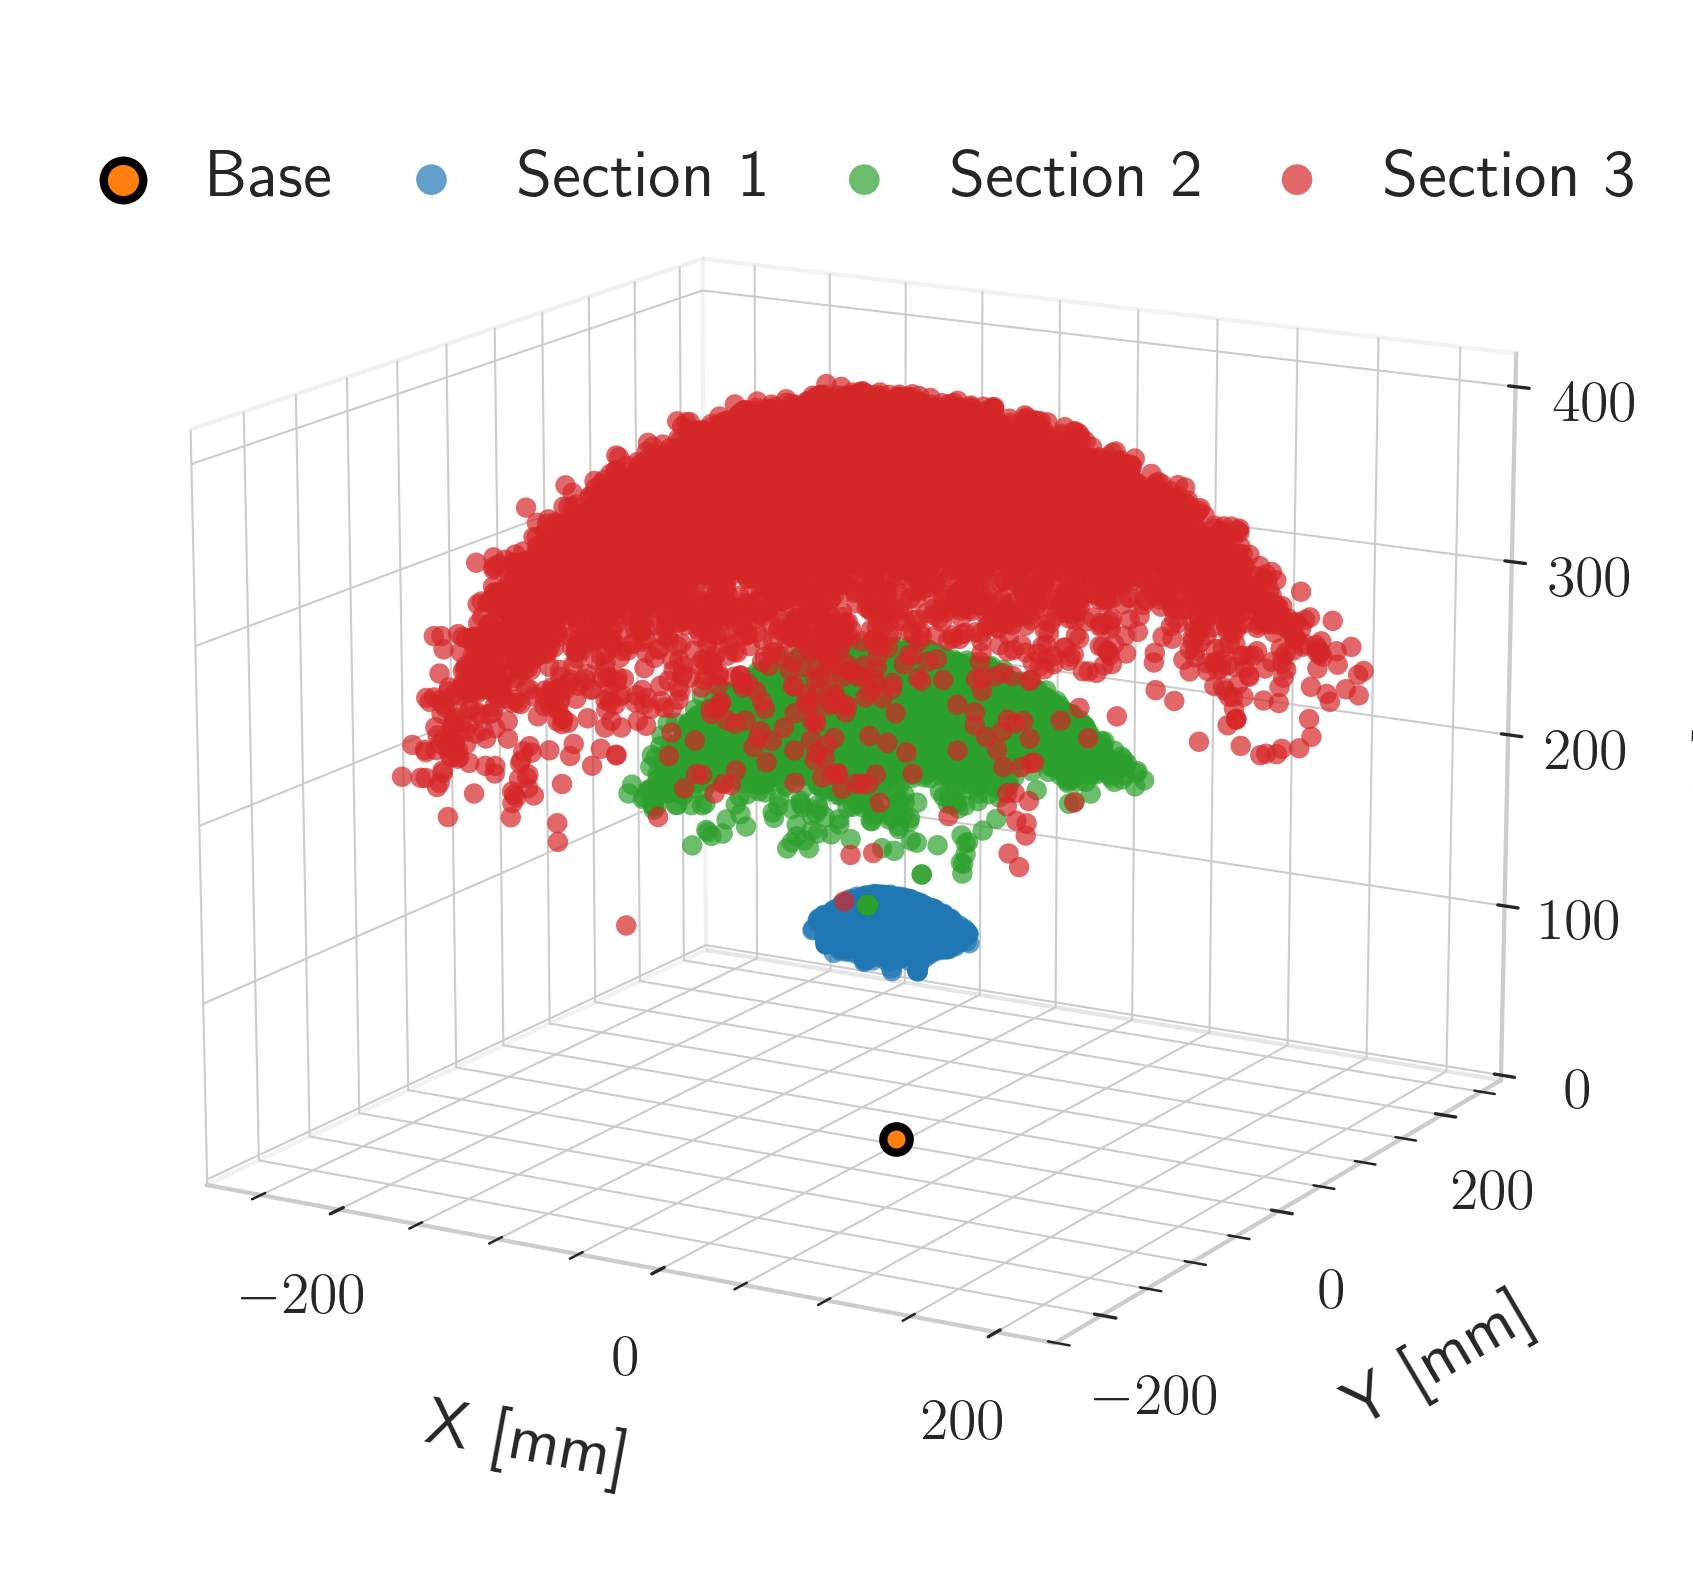

In [13]:
# Load the workspace data
data = np.load("Workspace.npz")
tip1 = data["tip1"]
tip2 = data["tip2"] 
tip3 = data["tip3"]

# Create publication-ready 3D plot - increased figure size to accommodate larger text
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Enhanced color scheme for publication
colors = {'sec1': '#1f77b4', 'sec2': '#2ca02c', 'sec3': '#d62728', 'base': '#ff7f0e'}

# Plot the three tip pointclouds with refined styling
ax.scatter(tip1[:, 0], tip1[:, 1], tip1[:, 2], 
          c=colors['sec1'], s=24, alpha=0.7, 
          edgecolors='none', label='Section 1')
ax.scatter(tip2[:, 0], tip2[:, 1], tip2[:, 2], 
          c=colors['sec2'], s=24, alpha=0.7, 
          edgecolors='none', label='Section 2')
ax.scatter(tip3[:, 0], tip3[:, 1], tip3[:, 2], 
          c=colors['sec3'], s=24, alpha=0.7, 
          edgecolors='none', label='Section 3')

# Plot base point at origin with enhanced styling
ax.scatter([0], [0], [0], 
          c=colors['base'], s=40, marker='o', 
          edgecolors='black', linewidth=2, label='Base', zorder=10)

# Professional axis labels with units - larger font
ax.set_xlabel('X [mm]', labelpad=12, fontsize=16)
ax.set_ylabel('Y [mm]', labelpad=12, fontsize=16)
ax.set_zlabel('Z [mm]', labelpad=12, fontsize=16)

# Create custom legend order and horizontal layout above plot - more compact
handles, labels = ax.get_legend_handles_labels()
order = [3, 0, 1, 2]  # Base is last in creation order, sections 1-3 are first
legend = ax.legend([handles[i] for i in order], [labels[i] for i in order],
                  loc='upper center', bbox_to_anchor=(0.5, 0.96), 
                  ncol=4, frameon=False, 
                  columnspacing=0.4, handletextpad=0.3, fontsize=16, markerscale=1.5)

# Optimal viewing angle for workspace visualization
ax.view_init(elev=15, azim=-60)

# Calculate axis limits for custom ticks
margin = 3  # mm
min_x = min(tip1[:, 0].min(), tip2[:, 0].min(), tip3[:, 0].min()) - margin
max_x = max(tip1[:, 0].max(), tip2[:, 0].max(), tip3[:, 0].max()) + margin
min_y = min(tip1[:, 1].min(), tip2[:, 1].min(), tip3[:, 1].min()) - margin
max_y = max(tip1[:, 1].max(), tip2[:, 1].max(), tip3[:, 1].max()) + margin
min_z = -margin
max_z = max(tip1[:, 2].max(), tip2[:, 2].max(), tip3[:, 2].max()) + margin

# Custom tick spacing - every 200 for x,y and every 100 for z
x_ticks = np.arange(np.ceil(min_x/200)*200, np.floor(max_x/200)*200 + 200, 200)
y_ticks = np.arange(np.ceil(min_y/200)*200, np.floor(max_y/200)*200 + 200, 200)
z_ticks = np.arange(np.ceil(min_z/100)*100, np.floor(max_z/100)*100 + 100, 100)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_zticks(z_ticks)

# Enhanced axis appearance - larger font for tick labels
ax.tick_params(axis='both', which='major', labelsize=14, pad=4)

# Grid styling for better depth perception
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('gray')
ax.yaxis.pane.set_edgecolor('gray')
ax.zaxis.pane.set_edgecolor('gray')
ax.xaxis.pane.set_alpha(0.1)
ax.yaxis.pane.set_alpha(0.1)
ax.zaxis.pane.set_alpha(0.1)

# Set equal aspect ratio and limits
ax.set_box_aspect([1, 1, 0.8])  # Slightly compressed Z for better view
ax.set_xlim([min_x, max_x])
ax.set_ylim([min_y, max_y])
ax.set_zlim([min_z, max_z])

# Maintain proportional margins
plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08)
plt.show()

## ⏰ 1. Testing pose reconstructor

In [14]:
# Model for denormalization
class DenormalizedModel(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        out = self.base_model(x)
        return out * self.std + self.mean

Plot results on all parameters in tip1, tip2, tip3

In [15]:
# Load only the TorchScript model
model = torch.jit.load("models/vision/helyx_model.pt", map_location=device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader_y:
        images = images.to(device)
        labels = labels.to(device)
        
        preds = model(images)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        
        del images, labels, preds

# Stack all predictions and labels
all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Convert angular part to degrees for display (indices 3,4,5 for tip1, 9,10,11 for tip2, 15,16,17 for tip3)
angle_indices = np.array([3, 4, 5, 9, 10, 11, 15, 16, 17])
all_preds_deg = all_preds.copy()
all_labels_deg = all_labels.copy()
all_preds_deg[:, angle_indices] = np.rad2deg(all_preds[:, angle_indices])
all_labels_deg[:, angle_indices] = np.rad2deg(all_labels[:, angle_indices])

# Section 1 (Tip 1) - Parameters 0-5
param_names_1 = [r'$X_1$ [mm]', r'$Y_1$ [mm]', r'$Z_1$ [mm]', r'$\mathrm{Yaw}_1$ [°]', r'$\mathrm{Pitch}_1$ [°]', r'$\mathrm{Roll}_1$ [°]']

mae_values_1 = []
std_values_1 = []

for i in range(6):
    idx = i  # First 6 parameters (0-5)
    errors = np.abs(all_preds_deg[:, idx] - all_labels_deg[:, idx])
    mae_values_1.append(np.mean(errors))
    std_values_1.append(np.std(errors))

# Section 2 (Tip 2) - Parameters 6-11
param_names_2 = [r'$X_2$ [mm]', r'$Y_2$ [mm]', r'$Z_2$ [mm]', r'$\mathrm{Yaw}_2$ [°]', r'$\mathrm{Pitch}_2$ [°]', r'$\mathrm{Roll}_2$ [°]']

mae_values_2 = []
std_values_2 = []

for i in range(6):
    idx = i + 6
    errors = np.abs(all_preds_deg[:, idx] - all_labels_deg[:, idx])
    mae_values_2.append(np.mean(errors))
    std_values_2.append(np.std(errors))

# Section 3 (Tip 3) - Parameters 12-17
param_names_3 = [r'$X_3$ [mm]', r'$Y_3$ [mm]', r'$Z_3$ [mm]', r'$\mathrm{Yaw}_3$ [°]', r'$\mathrm{Pitch}_3$ [°]', r'$\mathrm{Roll}_3$ [°]']

mae_values_3 = []
std_values_3 = []

for i in range(6):
    idx = i + 12
    errors = np.abs(all_preds_deg[:, idx] - all_labels_deg[:, idx])
    mae_values_3.append(np.mean(errors))
    std_values_3.append(np.std(errors))

# Create statistics tables for each section
import pandas as pd

# Section 1 statistics
stats_data_1 = {
    'Parameter': param_names_1,
    'MAE': [f"{mae:.2f}" for mae in mae_values_1],
    'Std': [f"{std:.2f}" for std in std_values_1]
}
stats_df_1 = pd.DataFrame(stats_data_1)
print("--- Section 1 Parameter-wise Error Statistics ---")
print(stats_df_1.to_string(index=False))

# Section 2 statistics
stats_data_2 = {
    'Parameter': param_names_2,
    'MAE': [f"{mae:.2f}" for mae in mae_values_2],
    'Std': [f"{std:.2f}" for std in std_values_2]
}
stats_df_2 = pd.DataFrame(stats_data_2)
print("\n--- Section 2 Parameter-wise Error Statistics ---")
print(stats_df_2.to_string(index=False))

# Section 3 statistics
stats_data_3 = {
    'Parameter': param_names_3,
    'MAE': [f"{mae:.2f}" for mae in mae_values_3],
    'Std': [f"{std:.2f}" for std in std_values_3]
}
stats_df_3 = pd.DataFrame(stats_data_3)
print("\n--- Section 3 Parameter-wise Error Statistics ---")
print(stats_df_3.to_string(index=False))

# Error Analysis Method 1: Standard Pose-Level Errors
print("\n--- Method 1: Standard Pose-Level Error Analysis ---")
for tip in range(3):
    pos_idx = [tip*6, tip*6+1, tip*6+2]
    rot_idx = [tip*6+3, tip*6+4, tip*6+5]
    
    pos_errors = np.linalg.norm(all_preds_deg[:,pos_idx] - all_labels_deg[:,pos_idx], axis=1)
    
    rot_errors = np.array([AngularDistance(np.deg2rad(all_preds_deg[i, rot_idx]), 
                                           np.deg2rad(all_labels_deg[i, rot_idx])) 
                          for i in range(len(all_preds_deg))]) * 180/np.pi
    
    print(f"Section {tip+1}: "
          f"Position {np.mean(pos_errors):.2f}±{np.std(pos_errors):.2f}mm | "
          f"Rotation {np.mean(rot_errors):.2f}±{np.std(rot_errors):.2f}°")

# Error Analysis Method 2: Normalized by Length
print("\n--- Method 2: Length-Normalized Error Analysis ---")
section_lengths = [150, 300, 450]  # Cumulative lengths in mm
max_bending_angle = 90  # Maximum expected bending angle in degrees

for tip in range(3):
    pos_idx = [tip*6, tip*6+1, tip*6+2]
    rot_idx = [tip*6+3, tip*6+4, tip*6+5]
    
    pos_errors = np.linalg.norm(all_preds_deg[:,pos_idx] - all_labels_deg[:,pos_idx], axis=1)
    normalized_pos_errors = (pos_errors / section_lengths[tip]) * 100  # %
    
    rot_errors = np.array([AngularDistance(np.deg2rad(all_preds_deg[i, rot_idx]), 
                                           np.deg2rad(all_labels_deg[i, rot_idx])) 
                          for i in range(len(all_preds_deg))]) * 180/np.pi
    normalized_rot_errors = (rot_errors / max_bending_angle) * 100  # %
    
    print(f"Section {tip+1}: "
          f"Position {np.mean(normalized_pos_errors):.2f}±{np.std(normalized_pos_errors):.2f}% | "
          f"Rotation {np.mean(normalized_rot_errors):.2f}±{np.std(normalized_rot_errors):.2f}%")

# Error Analysis Method 3: Relative Transformation Errors
def pose_to_transform(pose_6dof):
    x, y, z, yaw, pitch, roll = pose_6dof
    t = np.array([x, y, z])
    R_matrix = R.from_euler('zyx', [yaw, pitch, roll]).as_matrix()
    return R_matrix, t

def compute_relative_transform(R1, t1, R2, t2):
    R12 = R1.T @ R2
    t12 = R1.T @ (t2 - t1)
    return R12, t12

def rotation_matrix_to_euler(R_matrix):
    return R.from_matrix(R_matrix).as_euler('zyx')

print("\n--- Method 3: Relative Transformation Error Analysis ---")

base_pose = np.array([0, 0, 0, 0, 0, 0])
relative_errors_pos = []
relative_errors_rot = []
section_pairs = [("Base", "Tip1"), ("Tip1", "Tip2"), ("Tip2", "Tip3")]

n_samples = all_preds.shape[0]

for sample_idx in range(n_samples):
    sample_pred = all_preds[sample_idx]
    sample_label = all_labels[sample_idx]
    
    poses_pred = [base_pose] + [sample_pred[i*6:(i+1)*6] for i in range(3)]
    poses_label = [base_pose] + [sample_label[i*6:(i+1)*6] for i in range(3)]
    
    sample_rel_errors_pos = []
    sample_rel_errors_rot = []
    
    for i in range(3):  # Base→Tip1, Tip1→Tip2, Tip2→Tip3
        R1_pred, t1_pred = pose_to_transform(poses_pred[i])
        R2_pred, t2_pred = pose_to_transform(poses_pred[i+1])
        R1_label, t1_label = pose_to_transform(poses_label[i])
        R2_label, t2_label = pose_to_transform(poses_label[i+1])
        
        R12_pred, t12_pred = compute_relative_transform(R1_pred, t1_pred, R2_pred, t2_pred)
        R12_label, t12_label = compute_relative_transform(R1_label, t1_label, R2_label, t2_label)
        
        pos_error = np.linalg.norm(t12_pred - t12_label)
        rot_error = AngularDistance(rotation_matrix_to_euler(R12_pred), 
                                   rotation_matrix_to_euler(R12_label)) * 180/np.pi
        
        sample_rel_errors_pos.append(pos_error)
        sample_rel_errors_rot.append(rot_error)
    
    relative_errors_pos.append(sample_rel_errors_pos)
    relative_errors_rot.append(sample_rel_errors_rot)

relative_errors_pos = np.array(relative_errors_pos)
relative_errors_rot = np.array(relative_errors_rot)

for i, pair_name in enumerate(section_pairs):
    print(f"{pair_name[0]}→{pair_name[1]}: "
          f"Position {np.mean(relative_errors_pos[:, i]):.2f}±{np.std(relative_errors_pos[:, i]):.2f}mm | "
          f"Rotation {np.mean(relative_errors_rot[:, i]):.2f}±{np.std(relative_errors_rot[:, i]):.2f}°")


--- Section 1 Parameter-wise Error Statistics ---
             Parameter  MAE   Std
            $X_1$ [mm] 2.80  2.47
            $Y_1$ [mm] 2.50  2.19
            $Z_1$ [mm] 1.04  0.91
  $\mathrm{Yaw}_1$ [°] 1.66  4.25
$\mathrm{Pitch}_1$ [°] 3.38  2.85
 $\mathrm{Roll}_1$ [°] 4.62 16.26

--- Section 2 Parameter-wise Error Statistics ---
             Parameter  MAE  Std
            $X_2$ [mm] 8.30 7.19
            $Y_2$ [mm] 8.45 7.56
            $Z_2$ [mm] 3.71 3.30
  $\mathrm{Yaw}_2$ [°] 1.77 1.95
$\mathrm{Pitch}_2$ [°] 3.78 3.10
 $\mathrm{Roll}_2$ [°] 4.26 3.76

--- Section 3 Parameter-wise Error Statistics ---
             Parameter   MAE   Std
            $X_3$ [mm] 15.15 12.72
            $Y_3$ [mm] 15.78 14.22
            $Z_3$ [mm]  8.08  8.00
  $\mathrm{Yaw}_3$ [°]  4.41 13.64
$\mathrm{Pitch}_3$ [°]  4.32  4.25
 $\mathrm{Roll}_3$ [°]  6.99 15.80

--- Method 1: Standard Pose-Level Error Analysis ---
Section 1: Position 4.44±2.68mm | Rotation 6.78±15.94°
Section 2: Position 14.01

Plot errors on pose estimation, with different subplots (4 per tip)

Tip1 Test Data – Position Error
  Filtered 13 outliers (2.6%)


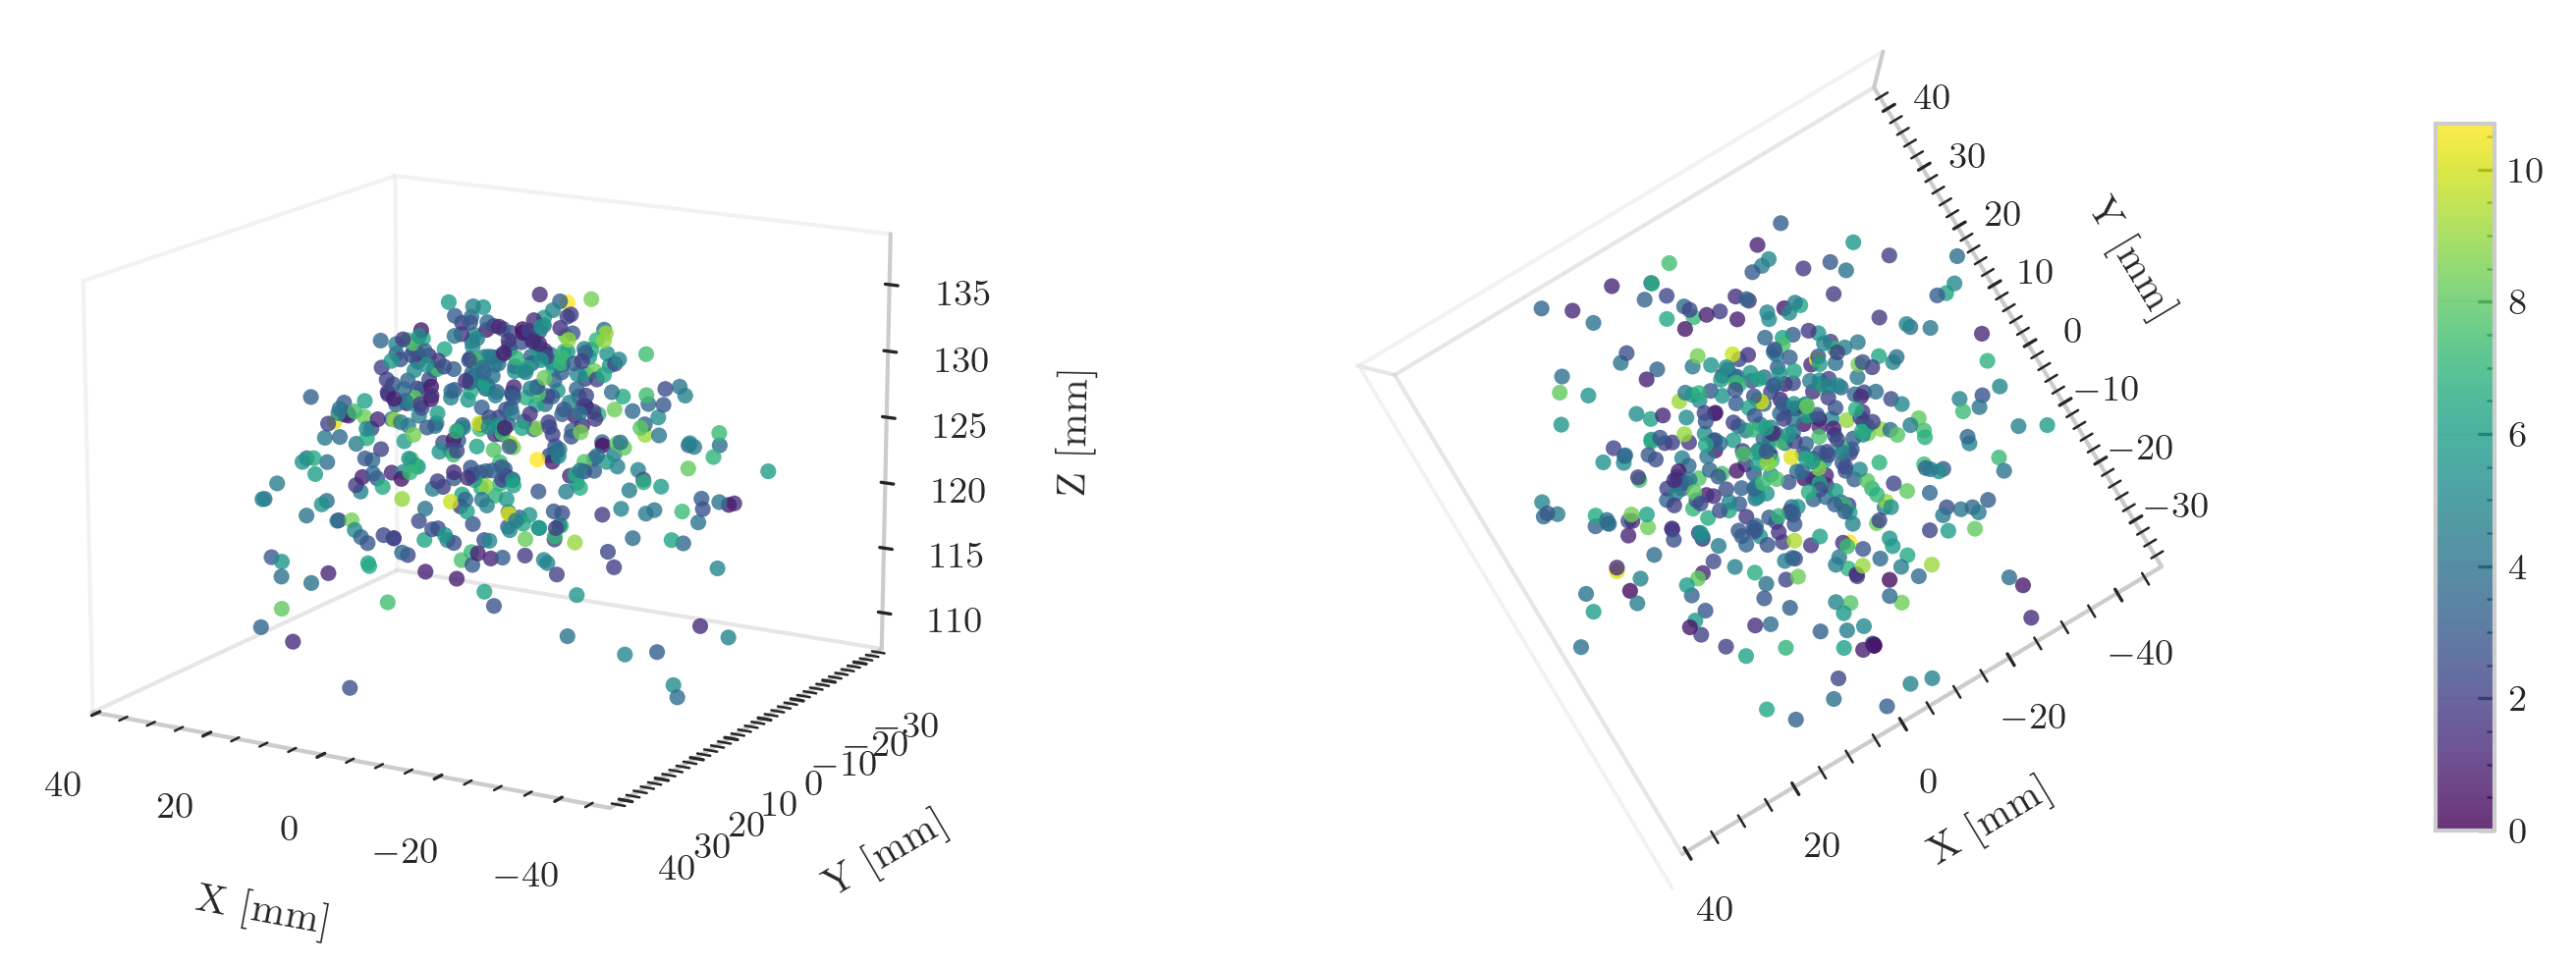

Tip1 Test Data – Orientation Error
  Filtered 13 outliers (2.6%)


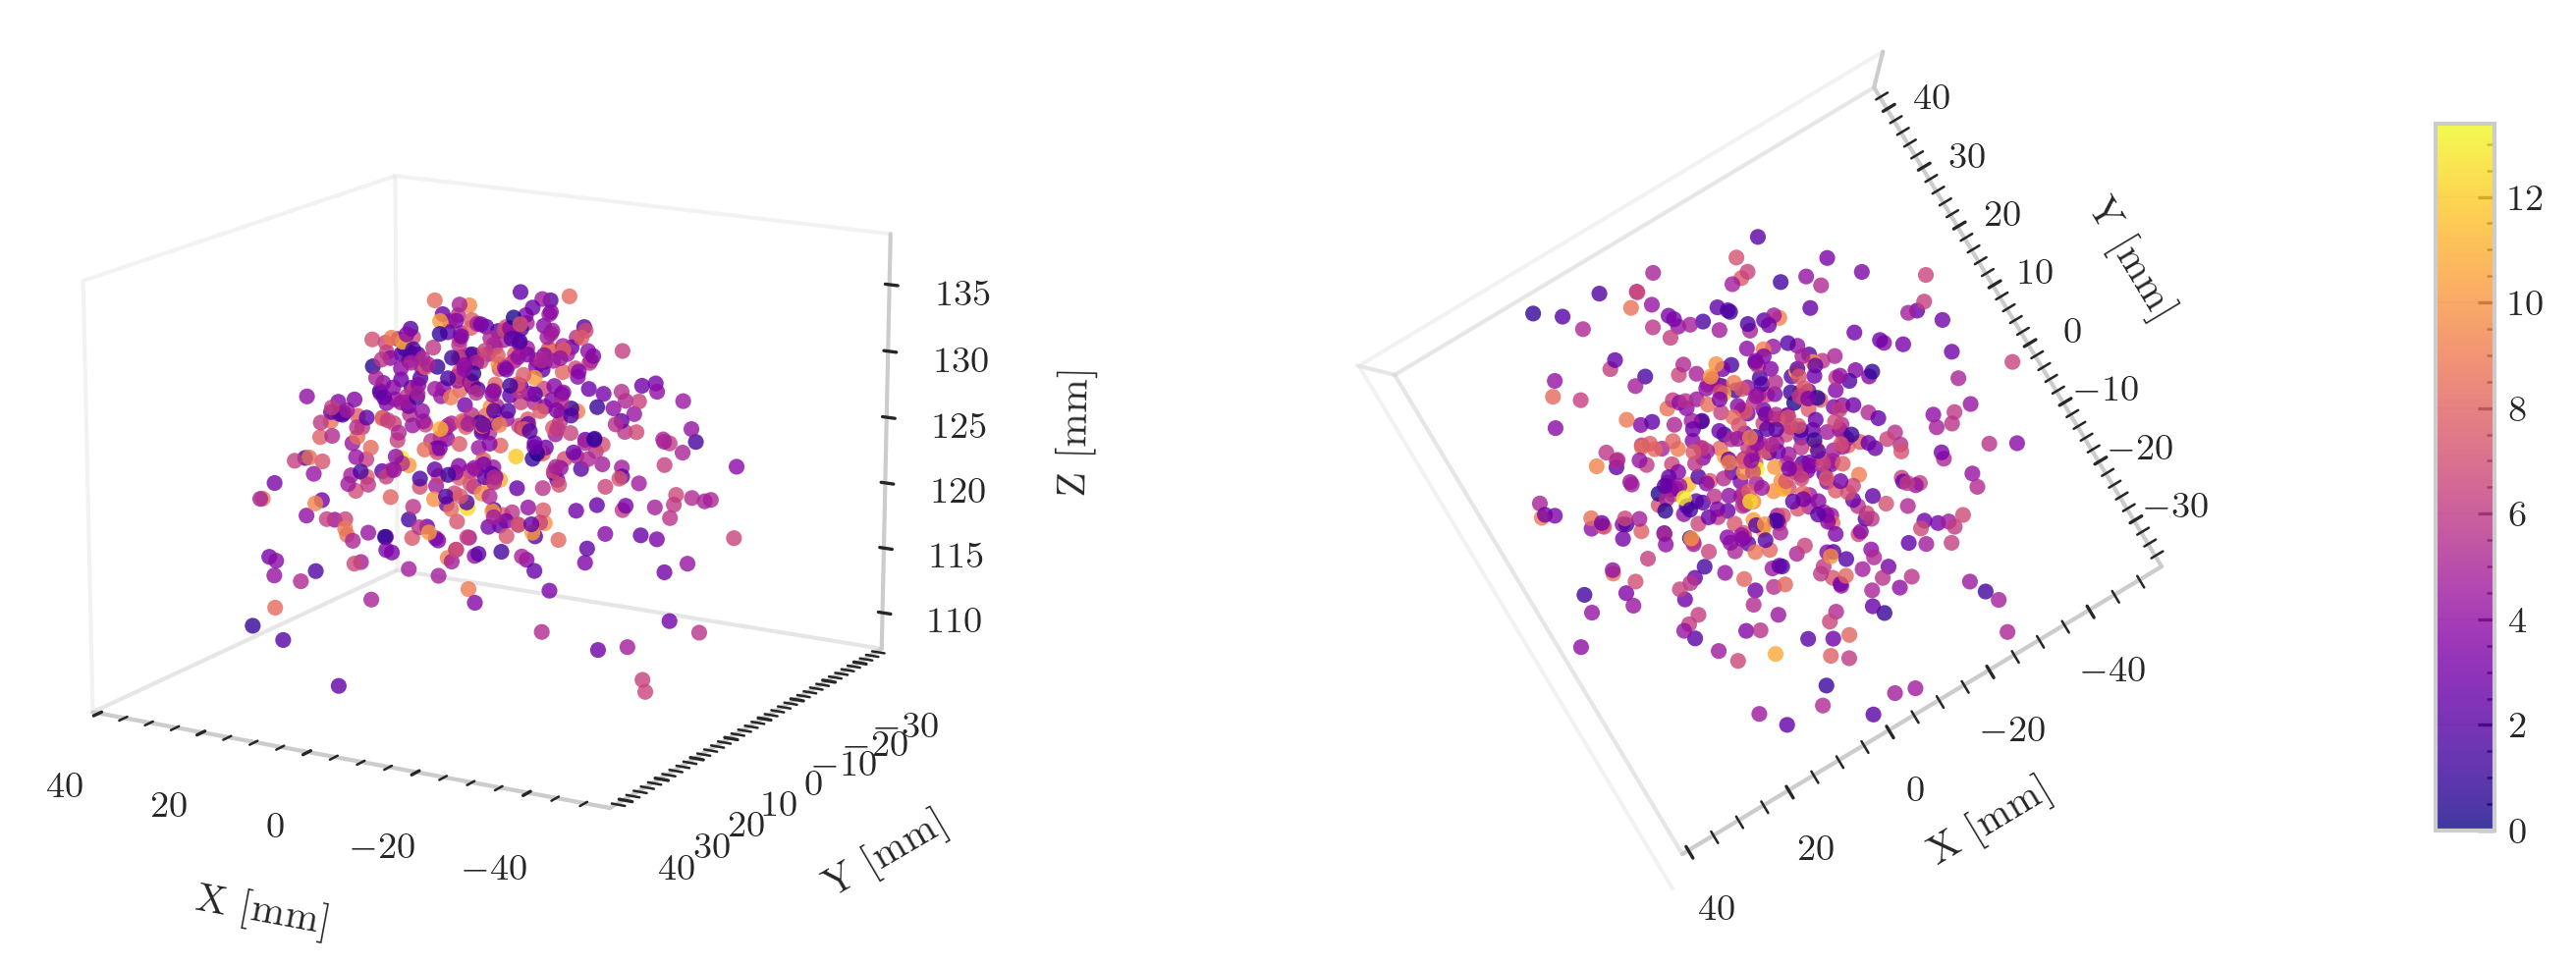

Tip2 Test Data – Position Error
  Filtered 13 outliers (2.6%)


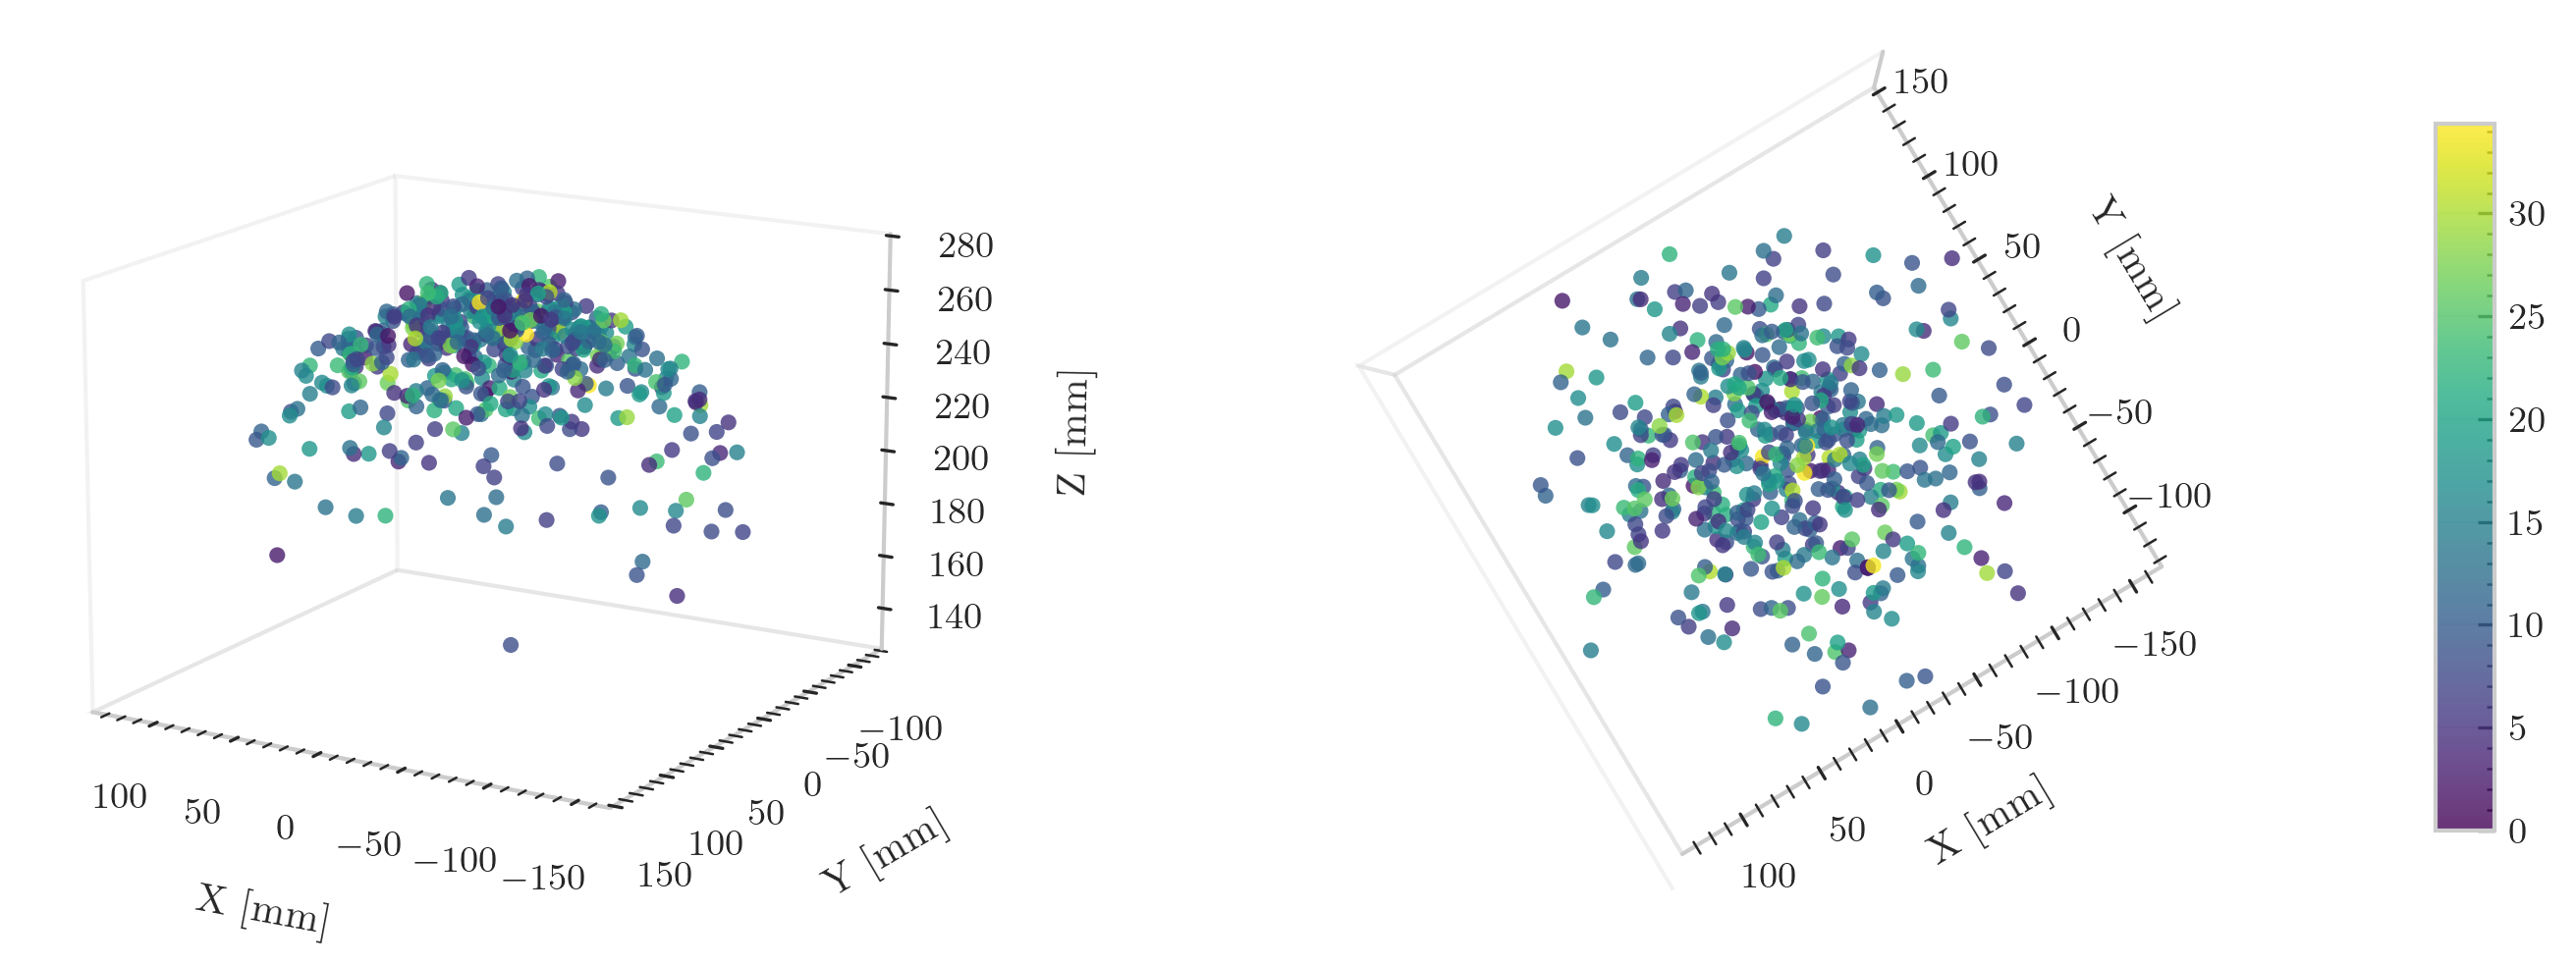

Tip2 Test Data – Orientation Error
  Filtered 13 outliers (2.6%)


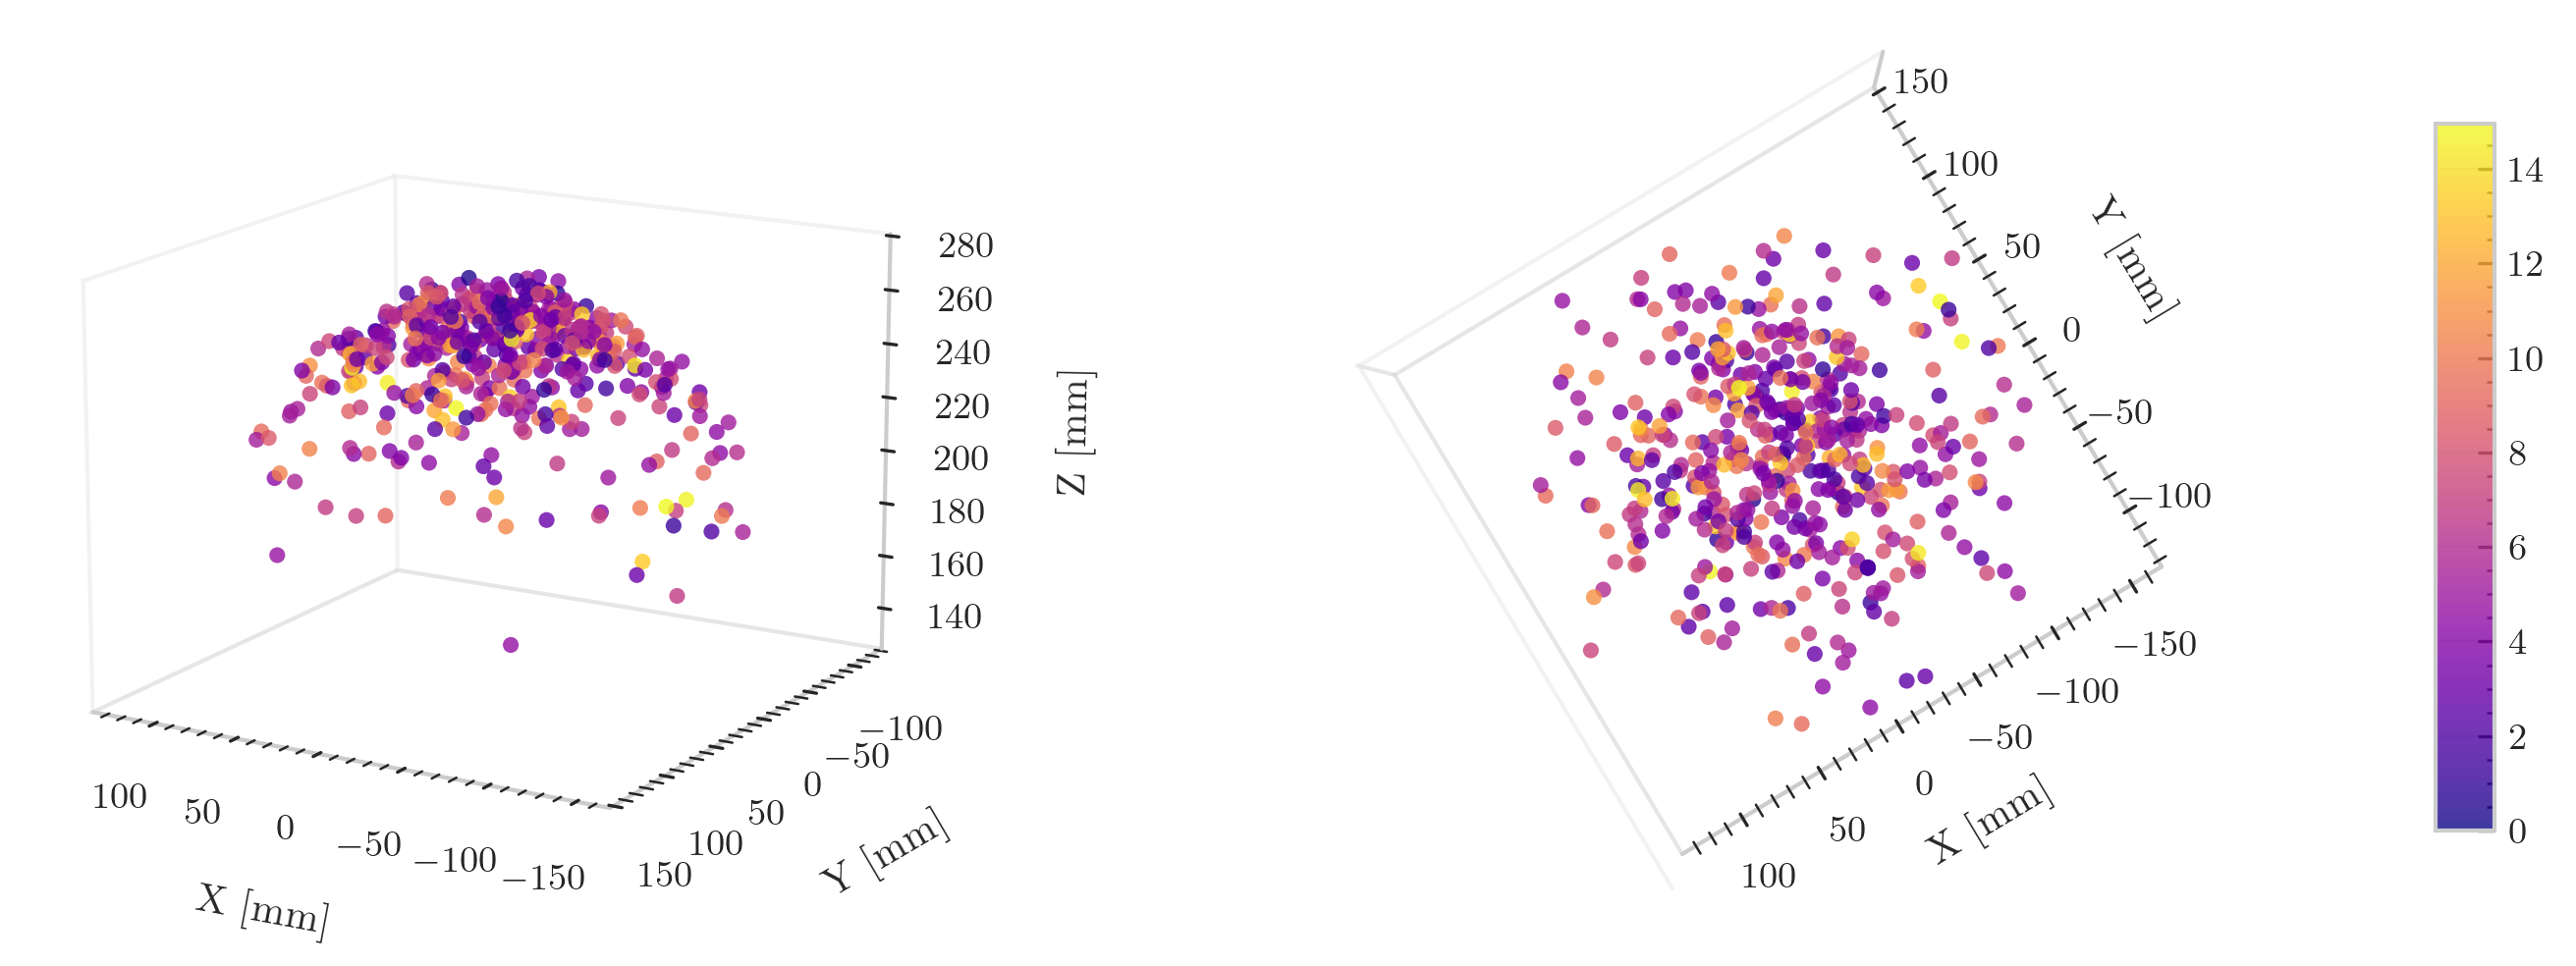

Tip3 Test Data – Position Error
  Filtered 13 outliers (2.6%)


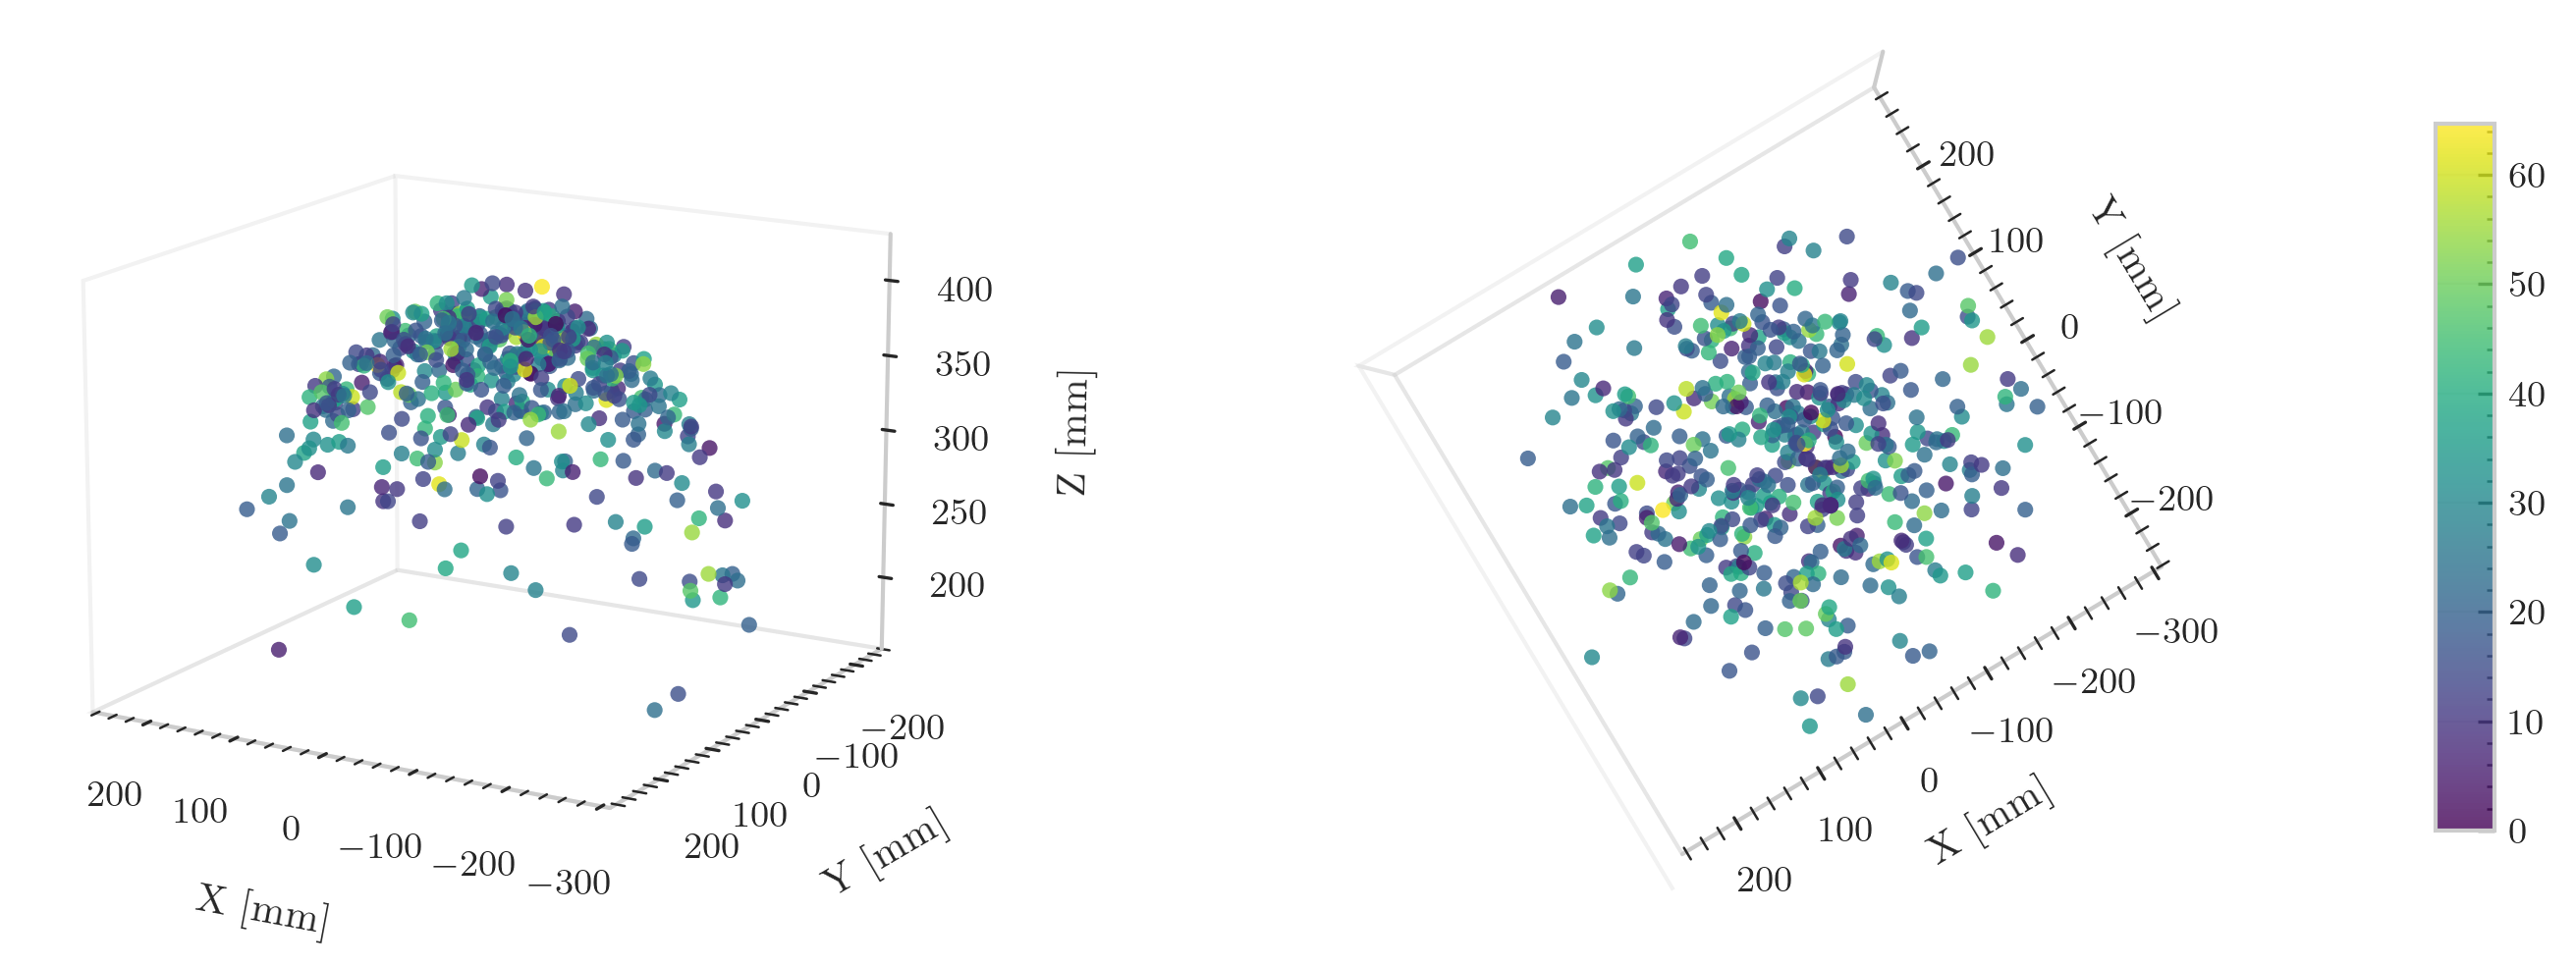

Tip3 Test Data – Orientation Error
  Filtered 13 outliers (2.6%)


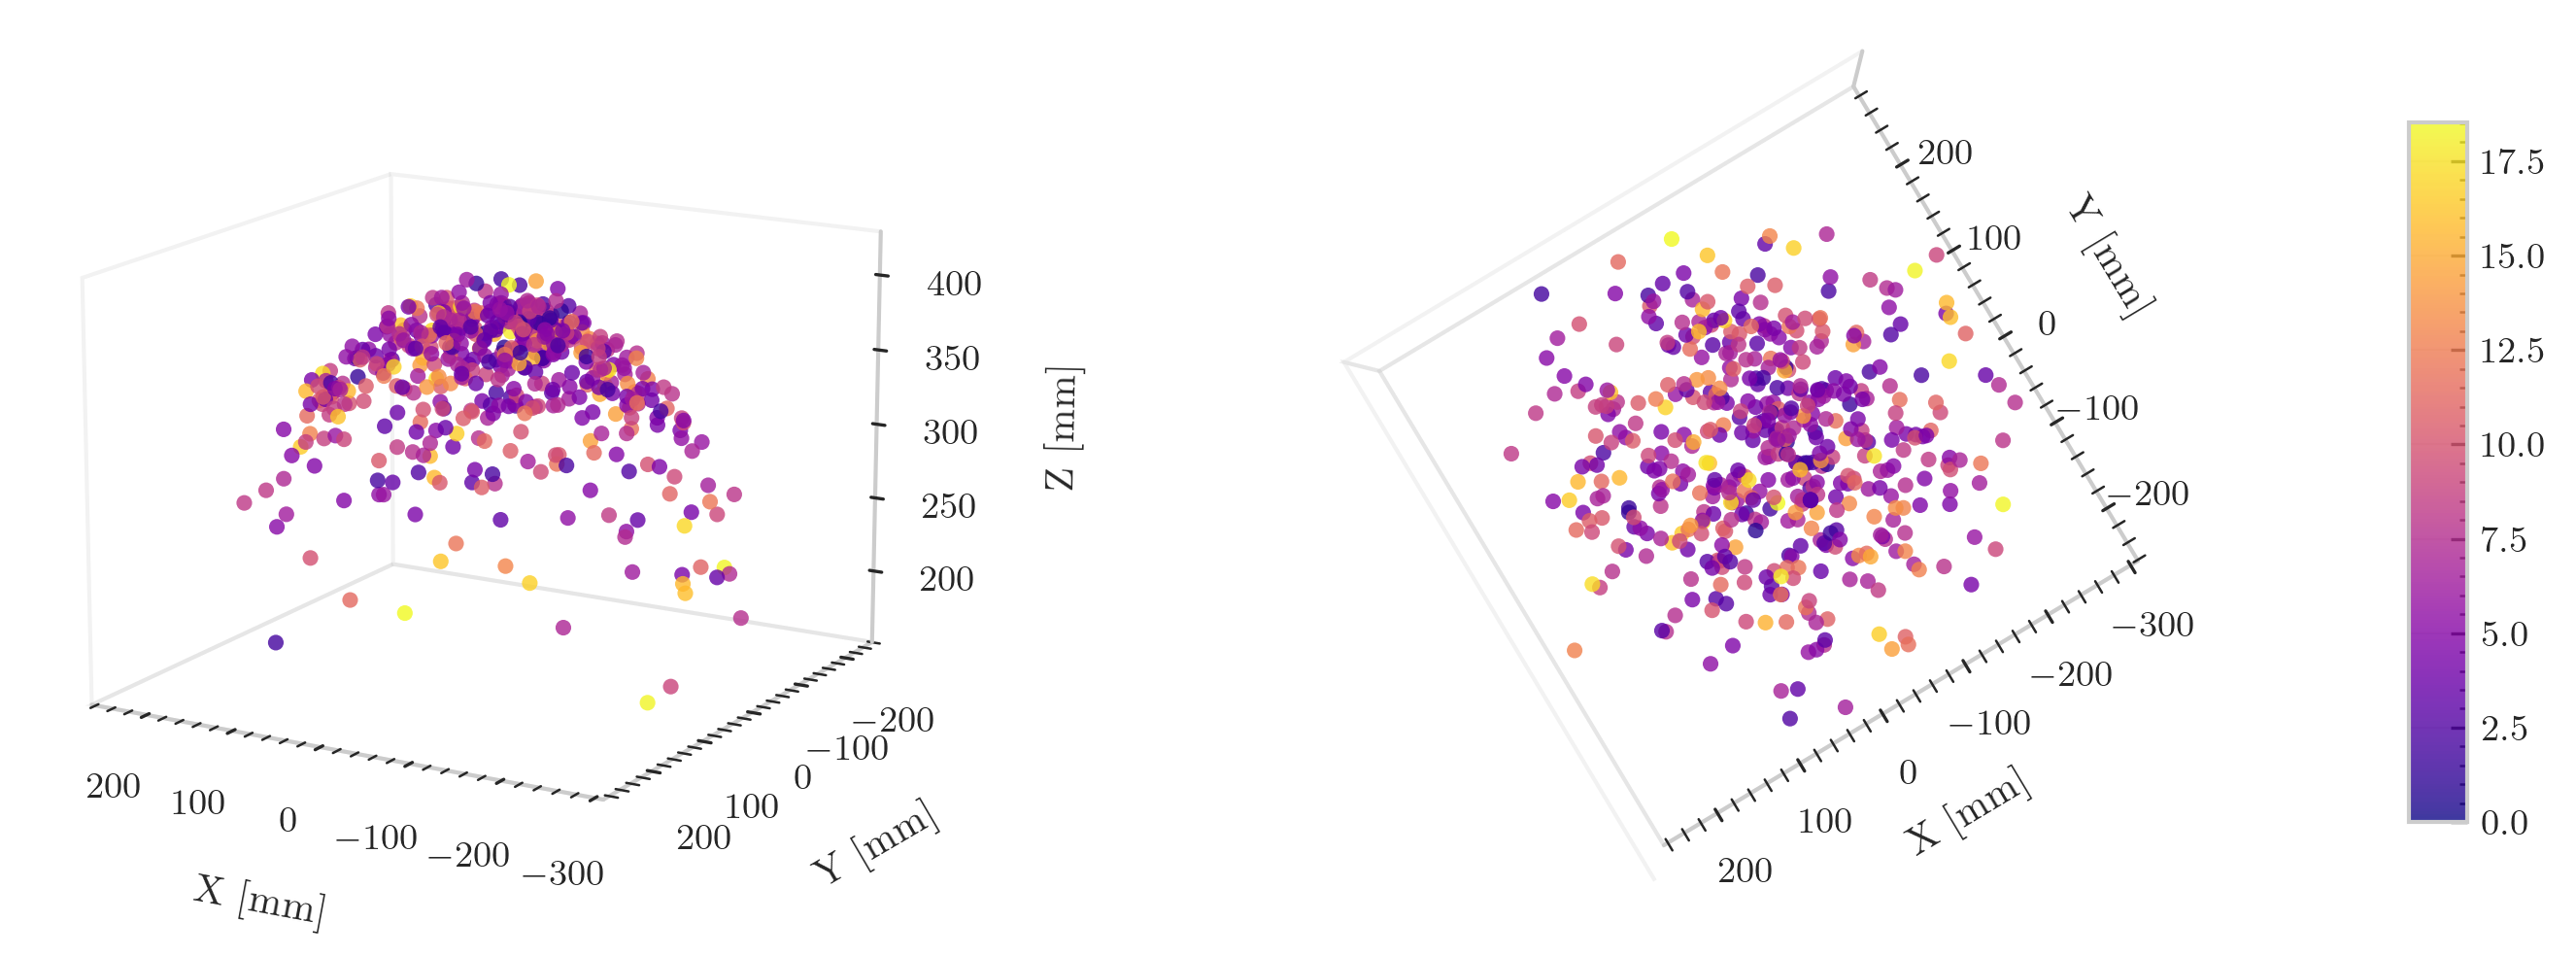

In [16]:
model = torch.jit.load("models/vision/helyx_model.pt", map_location=device)
model.eval()

train_preds, train_labels = [], []

with torch.no_grad():
   for images, labels in train_loader_y:
       images = images.to(device)
       labels = labels.to(device)
       preds = model(images)
       train_preds.append(preds.cpu().numpy())
       train_labels.append(labels.cpu().numpy())
       del images, labels, preds

with torch.no_grad():
   for images, labels in val_loader_y:
       images = images.to(device)
       labels = labels.to(device)
       preds = model(images)
       train_preds.append(preds.cpu().numpy())
       train_labels.append(labels.cpu().numpy())
       del images, labels, preds

angle_indices = np.array([3, 4, 5, 9, 10, 11, 15, 16, 17])
train_preds = np.concatenate(train_preds, axis=0)
train_labels = np.concatenate(train_labels, axis=0)
train_preds[:, angle_indices] = np.rad2deg(train_preds[:, angle_indices])
train_labels[:, angle_indices] = np.rad2deg(train_labels[:, angle_indices])

test_preds, test_labels = [], []

with torch.no_grad():
   for images, labels in test_loader_y:
       images = images.to(device)
       labels = labels.to(device)
       preds = model(images)
       test_preds.append(preds.cpu().numpy())
       test_labels.append(labels.cpu().numpy())
       del images, labels, preds

test_preds = np.concatenate(test_preds, axis=0)
test_labels = np.concatenate(test_labels, axis=0)
test_preds[:, angle_indices] = np.rad2deg(test_preds[:, angle_indices])
test_labels[:, angle_indices] = np.rad2deg(test_labels[:, angle_indices])

plt.rcParams.update({
   'font.size': 11,
   'font.family': 'serif',
   'axes.linewidth': 1.0,
   'xtick.major.size': 4,
   'xtick.minor.size': 2,
   'ytick.major.size': 4,
   'ytick.minor.size': 2,
   'xtick.direction': 'in',
   'ytick.direction': 'in'
})

def filter_outliers(coords, error, percentile=97.5):
    threshold = np.percentile(error, percentile)
    mask = error <= threshold
    return coords[mask], error[mask], mask

def plot_dual_view(coords, error, cmap, cbar_label, vmax, tip_num=None):
   fig = plt.figure(figsize=(10, 4))

   ax1 = fig.add_subplot(1, 2, 1, projection='3d')
   sc1 = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                     c=error, cmap=cmap, vmin=0, vmax=vmax, s=15, alpha=0.8, edgecolors='none')
   ax1.set_xlabel('X [mm]', labelpad=8)
   ax1.set_ylabel('Y [mm]', labelpad=8)
   ax1.set_zlabel('Z [mm]', labelpad=8)
   ax1.view_init(elev=15, azim=120)

   ax2 = fig.add_subplot(1, 2, 2, projection='3d')
   sc2 = ax2.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                     c=error, cmap=cmap, vmin=0, vmax=vmax, s=15, alpha=0.8, edgecolors='none')
   ax2.set_xlabel('X [mm]', labelpad=8)
   ax2.set_ylabel('Y [mm]', labelpad=8)
   ax2.set_zticks([])
   ax2.set_zlabel('')
   ax2.view_init(elev=-90, azim=120)

   for ax in [ax1, ax2]:
       ax.xaxis.pane.fill = False
       ax.yaxis.pane.fill = False
       ax.zaxis.pane.fill = False
       ax.xaxis.pane.set_edgecolor('gray')
       ax.yaxis.pane.set_edgecolor('gray')
       ax.zaxis.pane.set_edgecolor('gray')
       ax.xaxis.pane.set_alpha(0.1)
       ax.yaxis.pane.set_alpha(0.1)
       ax.zaxis.pane.set_alpha(0.1)
       ax.grid(False)

   cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
   cbar = fig.colorbar(sc1, cax=cbar_ax)
   cbar.ax.tick_params(labelsize=9)

   plt.subplots_adjust(left=0.05, right=0.9, wspace=0.05)
   plt.show()

# --- Only TEST PLOTS ---
for tip in [0, 1, 2]:
   test_tip_coords = test_labels[:, tip*6:tip*6+3]
   test_tip_pos = np.linalg.norm(test_preds[:, tip*6:tip*6+3] - test_labels[:, tip*6:tip*6+3], axis=1)
   test_tip_rot = np.array([AngularDistance(np.deg2rad(test_preds[i, tip*6+3:tip*6+6]), 
                                            np.deg2rad(test_labels[i, tip*6+3:tip*6+6])) 
                           for i in range(len(test_preds))]) * 180/np.pi

   test_tip_coords_filt, test_tip_pos_filt, test_pos_mask = filter_outliers(test_tip_coords, test_tip_pos, 97.5)
   _, test_tip_rot_filt, test_rot_mask = filter_outliers(test_tip_coords, test_tip_rot, 97.5)
   test_tip_coords_rot = test_tip_coords[test_rot_mask]

   max_pos = test_tip_pos_filt.max()
   max_rot = test_tip_rot_filt.max()

   print(f"Tip{tip+1} Test Data – Position Error")
   print(f"  Filtered {len(test_tip_pos) - len(test_tip_pos_filt)} outliers ({100*(len(test_tip_pos) - len(test_tip_pos_filt))/len(test_tip_pos):.1f}%)")
   plot_dual_view(test_tip_coords_filt, test_tip_pos_filt, 'viridis', "Position Error [mm]", max_pos, tip)

   print(f"Tip{tip+1} Test Data – Orientation Error")
   print(f"  Filtered {len(test_tip_rot) - len(test_tip_rot_filt)} outliers ({100*(len(test_tip_rot) - len(test_tip_rot_filt))/len(test_tip_rot):.1f}%)")
   plot_dual_view(test_tip_coords_rot, test_tip_rot_filt, 'plasma', "Orientation Error [°]", max_rot, tip)

plt.rcdefaults()


Ensemble figure

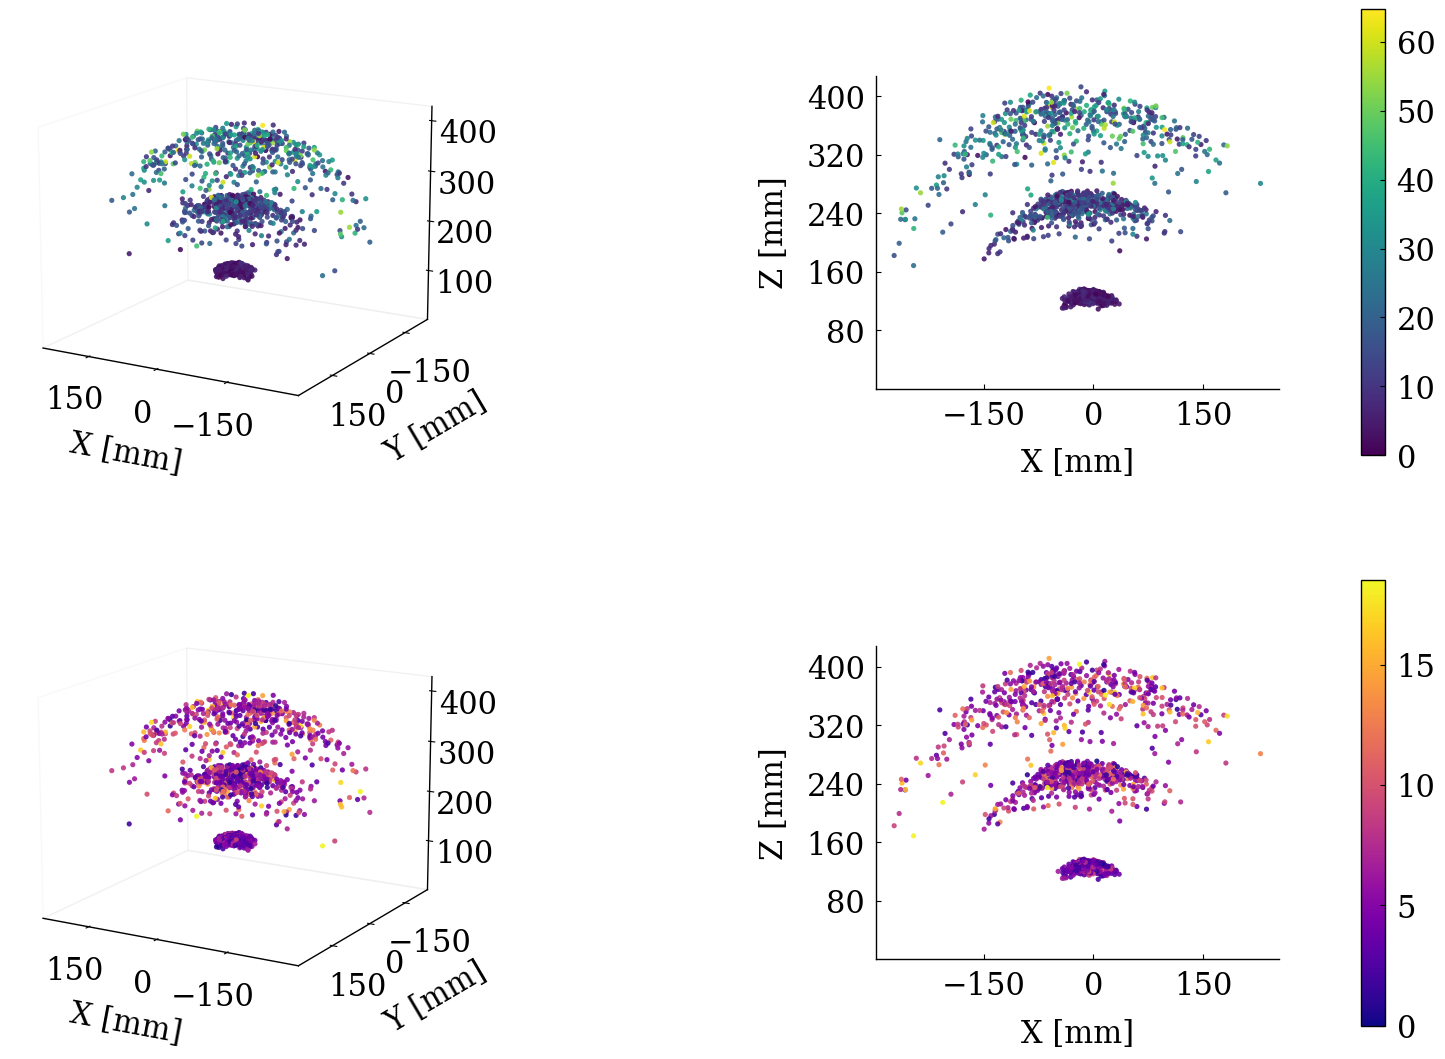

In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator

# --- collect per-tip results for the combined plot ---
test_pos_errors, test_rot_errors = [], []
test_coords_pos, test_coords_rot = [], []

for tip in [0, 1, 2]:
    test_tip_coords = test_labels[:, tip*6:tip*6+3]

    # position error
    test_tip_pos = np.linalg.norm(
        test_preds[:, tip*6:tip*6+3] - test_labels[:, tip*6:tip*6+3], axis=1
    )

    # orientation error
    test_tip_rot = np.array([
        AngularDistance(
            np.deg2rad(test_preds[i, tip*6+3:tip*6+6]),
            np.deg2rad(test_labels[i, tip*6+3:tip*6+6])
        )
        for i in range(len(test_preds))
    ]) * 180/np.pi

    # filter outliers (pos & rot separately)
    coords_pos_filt, pos_err_filt, _ = filter_outliers(test_tip_coords, test_tip_pos, 97.5)
    coords_rot_filt, rot_err_filt, _ = filter_outliers(test_tip_coords, test_tip_rot, 97.5)

    # append to lists
    test_coords_pos.append(coords_pos_filt)
    test_pos_errors.append(pos_err_filt)
    test_coords_rot.append(coords_rot_filt)
    test_rot_errors.append(rot_err_filt)

# -------- shared color scaling --------
all_pos_err = np.concatenate(test_pos_errors) if len(test_pos_errors) else np.array([1.0])
all_rot_err = np.concatenate(test_rot_errors) if len(test_rot_errors) else np.array([1.0])
vmax_pos = float(all_pos_err.max()) if all_pos_err.size else 1.0
vmax_rot = float(all_rot_err.max()) if all_rot_err.size else 1.0

cmap_pos, cmap_rot = 'viridis', 'plasma'
norm_pos = mpl.colors.Normalize(vmin=0.0, vmax=vmax_pos)
norm_rot = mpl.colors.Normalize(vmin=0.0, vmax=vmax_rot)

# -------- shared axis limits (Z starts at 0) --------
all_coords_for_limits = [a for a in (test_coords_pos + test_coords_rot) if a.size]
if len(all_coords_for_limits):
    all_coords_for_limits = np.vstack(all_coords_for_limits)

    # add a little padding
    pad_x = 0.05 * (all_coords_for_limits[:,0].ptp() + 1e-9)
    pad_y = 0.05 * (all_coords_for_limits[:,1].ptp() + 1e-9)
    pad_z = 0.05 * (all_coords_for_limits[:,2].ptp() + 1e-9)

    x_min, x_max = all_coords_for_limits[:,0].min() - pad_x, all_coords_for_limits[:,0].max() + pad_x
    y_min, y_max = all_coords_for_limits[:,1].min() - pad_y, all_coords_for_limits[:,1].max() + pad_y
    z_min, z_max = 0.0, all_coords_for_limits[:,2].max() + pad_z
else:
    # sensible fallbacks if everything was filtered out
    x_min, x_max = -1.0, 1.0
    y_min, y_max = -1.0, 1.0
    z_min, z_max = 0.0, 1.0

# aspect for 3D box
box_aspect = (x_max - x_min, y_max - y_min, z_max - z_min)

# -------- helpers to style axes (with your mods) --------
def style_3d(ax, show_zlabel=True):
    # increased label distance
    ax.set_xlabel('X [mm]', labelpad=24)
    ax.set_ylabel('Y [mm]', labelpad=24)
    if show_zlabel:
        ax.set_zlabel('Z [mm]', labelpad=18)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect(box_aspect)
    ax.view_init(elev=15, azim=120)

    # de-emphasize panes & grid
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(False)

    # avoid overlapping labels: fewer ticks + fixed spacing every 150 mm on X & Y
    ax.xaxis.set_major_locator(MultipleLocator(150))
    ax.yaxis.set_major_locator(MultipleLocator(150))
    ax.zaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

    # add padding between ticks and labels to reduce crowding
    ax.tick_params(axis='both', which='major', pad=8)

def style_xz(ax):
    ax.set_xlabel('X [mm]', labelpad=12)   # increased label distance
    ax.set_ylabel('Z [mm]', labelpad=12)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(z_min, z_max)
    ax.set_aspect('equal', adjustable='box')  # true XZ geometry

    # clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ticks: X every 150 mm; Z auto with limited count to avoid overlaps
    ax.xaxis.set_major_locator(MultipleLocator(150))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))

    ax.margins(x=0.02, y=0.02)
    ax.tick_params(axis='both', which='major', pad=8)

# -------- figure (impagination tweaks) --------
plt.rcParams.update({
   'font.size': 22,   # doubled font size
   'font.family': 'serif',
   'axes.linewidth': 1.0,
   'xtick.direction': 'in',
   'ytick.direction': 'in'
})

fig = plt.figure(figsize=(16.5, 10.5), constrained_layout=True)

# wider left column; slimmer colorbar column; tuned whitespace
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[2.2, 1.0, 0.06],
    wspace=0.15,
    hspace=0.18
)
# fine-tune constrained layout paddings (outer margins + inter-axes space)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.02, hspace=0.04)

# axes
ax_tl = fig.add_subplot(gs[0, 0], projection='3d')  # pos, perspective (bigger)
ax_tr = fig.add_subplot(gs[0, 1])                   # pos, XZ
ax_bl = fig.add_subplot(gs[1, 0], projection='3d')  # rot, perspective (bigger)
ax_br = fig.add_subplot(gs[1, 1])                   # rot, XZ

# scatters
ms = 14  # marker size
for coords, errs in zip(test_coords_pos, test_pos_errors):
    if coords.size:
        ax_tl.scatter(coords[:,0], coords[:,1], coords[:,2],
                      c=errs, cmap=cmap_pos, norm=norm_pos,
                      s=ms, alpha=0.9, linewidths=0, rasterized=True)
        ax_tr.scatter(coords[:,0], coords[:,2],
                      c=errs, cmap=cmap_pos, norm=norm_pos,
                      s=ms, alpha=0.9, linewidths=0, rasterized=True)

for coords, errs in zip(test_coords_rot, test_rot_errors):
    if coords.size:
        ax_bl.scatter(coords[:,0], coords[:,1], coords[:,2],
                      c=errs, cmap=cmap_rot, norm=norm_rot,
                      s=ms, alpha=0.9, linewidths=0, rasterized=True)
        ax_br.scatter(coords[:,0], coords[:,2],
                      c=errs, cmap=cmap_rot, norm=norm_rot,
                      s=ms, alpha=0.9, linewidths=0, rasterized=True)

# style axes (no Z label on left 3D plots)
style_3d(ax_tl, show_zlabel=False)
style_3d(ax_bl, show_zlabel=False)
style_xz(ax_tr)
style_xz(ax_br)

# colorbars in the third column (no labels)
sm_pos = mpl.cm.ScalarMappable(norm=norm_pos, cmap=cmap_pos); sm_pos.set_array([])
sm_rot = mpl.cm.ScalarMappable(norm=norm_rot, cmap=cmap_rot); sm_rot.set_array([])

cax_pos = fig.add_subplot(gs[0, 2])
cax_rot = fig.add_subplot(gs[1, 2])
cb1 = fig.colorbar(sm_pos, cax=cax_pos)
cb2 = fig.colorbar(sm_rot, cax=cax_rot)

# tighten colorbar ticks area a bit so bars look sleek and avoid overlap
cb1.ax.tick_params(pad=8)
cb2.ax.tick_params(pad=8)

# optional: save
# fig.savefig("test_errors_2x2_final.pdf", dpi=300, bbox_inches='tight')
plt.show()


## ⏰ Testing curvature approximations

Quadratic curvature model

In [55]:
# Load the model (predicts: Li, c0i, c1i, c2i, φi for i = 1, 2, 3)
model = torch.jit.load("models/curvature/quadratic_model.pt", map_location=device)
model.eval()

all_preds = []
all_labels = []

# Inference loop
with torch.no_grad():
    for images, labels in curvature_loaders["quad"]["test"]:
        images = images.to(device)
        labels = labels.to(device)

        preds = model(images)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        del images, labels, preds

# Stack predictions and ground truth
all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Extract φ and convert to degrees
phi_indexes = [4, 9, 14]
phi_pred = np.rad2deg(all_preds[:, phi_indexes])
phi_true = np.rad2deg(all_labels[:, phi_indexes])

# Parameter names
base_names = ['S', r'c_0', r'c_1', r'c_2']
units = ['mm', '', '', '']

for tip in range(3):
    S_idx = tip*5
    c0_idx = tip*5 + 1
    c1_idx = tip*5 + 2
    c2_idx = tip*5 + 3

    # Extract parameters S, c0, c1, c2
    S = all_preds[:, S_idx]
    c0 = all_preds[:, c0_idx] 
    c1 = all_preds[:, c1_idx]
    c2 = all_preds[:, c2_idx]
    S_true = all_labels[:, S_idx]
    c0_true = all_labels[:, c0_idx]
    c1_true = all_labels[:, c1_idx] 
    c2_true = all_labels[:, c2_idx]

    # True pi computation
    n_points = 100
    v = np.linspace(0, 1, n_points)

    S_true_expanded = S_true[:, None] * v[None, :]
    theta_true = (
        c0_true[:, None] * S_true_expanded
        + 0.5 * c1_true[:, None] * S_true_expanded**2
        + (1 / 3) * c2_true[:, None] * S_true_expanded**3
    )
    sin_theta_true = np.sin(theta_true)
    pi_true = np.trapz(sin_theta_true, S_true_expanded, axis=1)

    # Parameter names with proper subscripts
    subscripts = ['₁', '₂', '₃']
    param_names = []
    for name, unit in zip(base_names, units):
        if name == 'S':
            param_name = f'S{subscripts[tip]} [{unit}]' if unit else f'S{subscripts[tip]}'
        elif name == r'c_0':
            param_name = f'c₀{subscripts[tip]} [{unit}]' if unit else f'c₀{subscripts[tip]}'
        elif name == r'c_1':
            param_name = f'c₁{subscripts[tip]} [{unit}]' if unit else f'c₁{subscripts[tip]}'
        elif name == r'c_2':
            param_name = f'c₂{subscripts[tip]} [{unit}]' if unit else f'c₂{subscripts[tip]}'
        param_names.append(param_name)

    # Calculate statistics
    mae_values = []
    std_values = []

    for i in range(4):
        errors = np.abs(all_preds[:, tip * 5 + i] - all_labels[:, tip * 5 + i])
        mae = np.mean(errors)
        std = np.std(errors)
        mae_values.append(mae)
        std_values.append(std)

    # Angle difference wrapped to [0°, 180°]
    delta_phi = np.abs((phi_pred[:, tip] - phi_true[:, tip] + 180) % 360 - 180)
    mae_phi = np.mean(delta_phi)
    std_phi = np.std(delta_phi)

    # Create statistics table
    import pandas as pd

    param_stats_data = {
        'Parameter': param_names,
        'MAE': [f"{mae:.2e}" if i in [1,2,3] else f"{mae:.2f}" for i, mae in enumerate(mae_values)],
        'Std': [f"{std:.2e}" if i in [1,2,3] else f"{std:.2f}" for i, std in enumerate(std_values)]
    }

    param_stats_df = pd.DataFrame(param_stats_data)

    angle_stats_data = {
        'Error Type': [rf'Angular Error φ_{{{tip+1}}} [°]'],
        'MAE': [f"{mae_phi:.2f}"],
        'Std': [f"{std_phi:.2f}"]
    }

    angle_stats_df = pd.DataFrame(angle_stats_data)

    # Print results
    print("=" * 50)
    print(f"SECTION {tip+1} EVALUATION RESULTS")
    print("=" * 50)

    print("\n--- Parameter-wise Error Statistics ---")
    print(param_stats_df.to_string(index=False))

    print("\n--- Angular Error Statistics ---")
    print(angle_stats_df.to_string(index=False))


SECTION 1 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
Parameter      MAE      Std
  S₁ [mm]     0.94     0.75
      c₀₁ 3.93e-04 3.45e-04
      c₁₁ 1.11e-05 1.21e-05
      c₂₁ 8.53e-08 8.95e-08

--- Angular Error Statistics ---
             Error Type   MAE   Std
Angular Error φ_{1} [°] 25.46 34.08
SECTION 2 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
Parameter      MAE      Std
  S₂ [mm]     1.69     3.80
      c₀₂ 7.27e-04 2.08e-03
      c₁₂ 1.56e-05 2.67e-05
      c₂₂ 1.02e-07 9.74e-08

--- Angular Error Statistics ---
             Error Type   MAE   Std
Angular Error φ_{2} [°] 28.48 32.96
SECTION 3 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
Parameter      MAE      Std
  S₃ [mm]     1.06     0.97
      c₀₃ 5.24e-04 7.24e-04
      c₁₃ 1.26e-05 1.28e-05
      c₂₃ 9.44e-08 9.60e-08

--- Angular Error Statistics ---
             Error Type   MAE   Std
Angular Error φ_{3} [°] 26.10 30.30


Affine curvature model

In [19]:
# Load the model (predicts: Li, c0i, c1i, φi for i = 1, 2, 3)
model = torch.jit.load("models/curvature/affine_model.pt", map_location=device)
model.eval()

all_preds = []
all_labels = []

# Inference loop
with torch.no_grad():
    for images, labels in curvature_loaders["affine"]["test"]:
        images = images.to(device)
        labels = labels.to(device)

        preds = model(images)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        del images, labels, preds

# Stack predictions and ground truth
all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Extract φ and convert to degrees
phi_indexes = [3, 7, 11]
phi_pred = np.rad2deg(all_preds[:, phi_indexes])
phi_true = np.rad2deg(all_labels[:, phi_indexes])

# Parameters
base_names = ['S', r'c_0', r'c_1']
units = ['mm', '', '']

for tip in range(3):
    S_idx = tip * 4
    c0_idx = tip * 4 + 1
    c1_idx = tip * 4 + 2

    # Extract parameters
    S = all_preds[:, S_idx]
    c0 = all_preds[:, c0_idx]
    c1 = all_preds[:, c1_idx]
    S_true = all_labels[:, S_idx]
    c0_true = all_labels[:, c0_idx]
    c1_true = all_labels[:, c1_idx]

    # True pi computation
    n_points = 100
    v = np.linspace(0, 1, n_points)

    S_true_expanded = S_true[:, None] * v[None, :]
    theta_true = c0_true[:, None] * S_true_expanded + 0.5 * c1_true[:, None] * S_true_expanded ** 2
    sin_theta_true = np.sin(theta_true)
    pi_true = np.trapz(sin_theta_true, S_true_expanded, axis=1)

    # Parameter names with subscripts
    subscripts = ['₁', '₂', '₃']
    param_names = []
    for name, unit in zip(base_names, units):
        if name == 'S':
            param_name = f'S{subscripts[tip]} [{unit}]' if unit else f'S{subscripts[tip]}'
        elif name == r'c_0':
            param_name = f'c₀{subscripts[tip]} [{unit}]' if unit else f'c₀{subscripts[tip]}'
        elif name == r'c_1':
            param_name = f'c₁{subscripts[tip]} [{unit}]' if unit else f'c₁{subscripts[tip]}'
        param_names.append(param_name)

    # Calculate statistics
    mae_values = []
    std_values = []

    for i in range(3):
        errors = np.abs(all_preds[:, tip * 4 + i] - all_labels[:, tip * 4 + i])
        mae = np.mean(errors)
        std = np.std(errors)
        mae_values.append(mae)
        std_values.append(std)

    # Angular error
    delta_phi = np.abs((phi_pred[:, tip] - phi_true[:, tip] + 180) % 360 - 180)
    mae_phi = np.mean(delta_phi)
    std_phi = np.std(delta_phi)

    # Create statistics tables
    import pandas as pd

    param_stats_data = {
        'Parameter': param_names,
        'MAE': [f"{mae:.2e}" if i in [1,2] else f"{mae:.2f}" for i, mae in enumerate(mae_values)],
        'Std': [f"{std:.2e}" if i in [1,2] else f"{std:.2f}" for i, std in enumerate(std_values)]
    }
    param_stats_df = pd.DataFrame(param_stats_data)

    angle_stats_data = {
        'Error Type': [rf'Angular Error φ_{{{tip+1}}} [°]'],
        'MAE': [f"{mae_phi:.2f}"],
        'Std': [f"{std_phi:.2f}"]
    }
    angle_stats_df = pd.DataFrame(angle_stats_data)

    # Print results
    print("=" * 50)
    print(f"SECTION {tip+1} EVALUATION RESULTS")
    print("=" * 50)

    print("\n--- Parameter-wise Error Statistics ---")
    print(param_stats_df.to_string(index=False))

    print("\n--- Angular Error Statistics ---")
    print(angle_stats_df.to_string(index=False))


SECTION 1 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
Parameter      MAE      Std
  S₁ [mm]     0.92     0.76
      c₀₁ 3.86e-04 3.19e-04
      c₁₁ 1.76e-06 1.72e-06

--- Angular Error Statistics ---
             Error Type   MAE   Std
Angular Error φ_{1} [°] 25.25 34.90
SECTION 2 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
Parameter      MAE      Std
  S₂ [mm]     1.64     4.07
      c₀₂ 7.15e-04 2.00e-03
      c₁₂ 3.20e-06 1.10e-05

--- Angular Error Statistics ---
             Error Type   MAE   Std
Angular Error φ_{2} [°] 30.07 32.75
SECTION 3 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
Parameter      MAE      Std
  S₃ [mm]     1.14     1.11
      c₀₃ 4.62e-04 6.44e-04
      c₁₃ 2.45e-06 3.26e-06

--- Angular Error Statistics ---
             Error Type   MAE   Std
Angular Error φ_{3} [°] 26.82 34.99


Constant curvature model

In [20]:
# Load the model (predicts: Li, c0i, φi for i = 1, 2, 3)
model = torch.jit.load("models/curvature/constant_model.pt", map_location=device)
model.eval()

all_preds = []
all_labels = []

# Inference loop
with torch.no_grad():
    for images, labels in curvature_loaders["const"]["test"]:
        images = images.to(device)
        labels = labels.to(device)

        preds = model(images)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        del images, labels, preds

# Stack predictions and ground truth
all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Extract φ and convert to degrees
phi_indexes = [2, 5, 8]
phi_pred = np.rad2deg(all_preds[:, phi_indexes])
phi_true = np.rad2deg(all_labels[:, phi_indexes])

# Parameters
base_names = ['S', r'c_0']
units = ['mm', '']

for tip in range(3):
    S_idx = tip * 3
    c0_idx = tip * 3 + 1

    # Extract parameters S, c0
    S = all_preds[:, S_idx]
    c0 = all_preds[:, c0_idx]
    S_true = all_labels[:, S_idx]
    c0_true = all_labels[:, c0_idx]

    # True pi computation
    n_points = 100
    v = np.linspace(0, 1, n_points)
    S_true_expanded = S_true[:, None] * v[None, :]
    theta_true = c0_true[:, None] * S_true_expanded
    sin_theta_true = np.sin(theta_true)
    pi_true = np.trapz(sin_theta_true, S_true_expanded, axis=1)

    # Parameter names with proper subscripts
    subscripts = ['₁', '₂', '₃']
    param_names = []
    for name, unit in zip(base_names, units):
        if name == 'S':
            param_name = f'S{subscripts[tip]} [{unit}]' if unit else f'S{subscripts[tip]}'
        elif name == r'c_0':
            param_name = f'c₀{subscripts[tip]} [{unit}]' if unit else f'c₀{subscripts[tip]}'
        param_names.append(param_name)

    # Calculate statistics
    mae_values = []
    std_values = []
    for i in range(2):
        errors = np.abs(all_preds[:, tip * 3 + i] - all_labels[:, tip * 3 + i])
        mae = np.mean(errors)
        std = np.std(errors)
        mae_values.append(mae)
        std_values.append(std)

    # Angular error (wrapped to [0°, 180°])
    delta_phi = np.abs((phi_pred[:, tip] - phi_true[:, tip] + 180) % 360 - 180)
    mae_phi = np.mean(delta_phi)
    std_phi = np.std(delta_phi)

    # Create statistics table
    import pandas as pd
    param_stats_data = {
        'Parameter': param_names,
        'MAE': [f"{mae:.2e}" if i == 1 else f"{mae:.2f}" for i, mae in enumerate(mae_values)],
        'Std': [f"{std:.2e}" if i == 1 else f"{std:.2f}" for i, std in enumerate(std_values)]
    }
    param_stats_df = pd.DataFrame(param_stats_data)

    angle_stats_data = {
        'Error Type': [rf'Angular Error φ_{{{tip+1}}} [°]'],
        'MAE': [f"{mae_phi:.2f}"],
        'Std': [f"{std_phi:.2f}"]
    }
    angle_stats_df = pd.DataFrame(angle_stats_data)

    # Print results
    print("=" * 50)
    print(f"SECTION {tip+1} EVALUATION RESULTS")
    print("=" * 50)

    print("\n--- Parameter-wise Error Statistics ---")
    print(param_stats_df.to_string(index=False))

    print("\n--- Angular Error Statistics ---")
    print(angle_stats_df.to_string(index=False))


SECTION 1 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
Parameter      MAE      Std
  S₁ [mm]     0.88     0.78
      c₀₁ 3.29e-04 2.62e-04

--- Angular Error Statistics ---
             Error Type   MAE   Std
Angular Error φ_{1} [°] 25.36 33.88
SECTION 2 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
Parameter      MAE      Std
  S₂ [mm]     1.48     3.68
      c₀₂ 5.26e-04 9.77e-04

--- Angular Error Statistics ---
             Error Type   MAE   Std
Angular Error φ_{2} [°] 29.48 35.29
SECTION 3 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
Parameter      MAE      Std
  S₃ [mm]     0.97     0.92
      c₀₃ 3.77e-04 4.13e-04

--- Angular Error Statistics ---
             Error Type   MAE   Std
Angular Error φ_{3} [°] 23.11 30.30


## ⏰ Plot body reconstructions

In [18]:
# Class for polynomial plotting
class PlotCurvature:
    """
    Defines plotting arrays (x, y, z) in the curvature approximation.
    """

    def __init__(self):
        pass

    def _translations(self, S, c0, c1, c2, phi):
        """
        Computes translations from curvature approximation.
        Inputs:
        - S: length of the (curved) central axis
        - c0, c1, c2: coefficients of the curvature approximation
        - phi: angle of the bending plane
        Output:
        - t: translation vector, in relative coordinates
        """

        v = np.linspace(0, S, 1000)
        integrand_z = np.cos(c0*v + 0.5*c1*v**2 + (1/3)*c2*v**3)
        tz = cumulative_trapezoid(integrand_z, v, initial=0.0)
        integrand_pi = np.sin(c0*v + 0.5*c1*v**2 + (1/3)*c2*v**3)
        pi = cumulative_trapezoid(integrand_pi, v, initial=0.0)
        tx = np.cos(phi) * pi
        ty = np.sin(phi) * pi
        return np.array([tx, ty, tz])
    
    def _rotations(self, S, c0, c1, c2, phi):
        """
        Computes rotations from curvature approximation.
        Inputs:
        - S: length of the (curved) central axis
        - c0, c1, c2: coefficients of the curvature approximation
        - phi: angle of the bending plane
        Output:
        - Rotation matrix of the tip, according to Della Santina.
        """

        s = np.linspace(0, S, 1000)
        theta = c0 * s + 0.5 * c1 * s ** 2 + (1/3) * c2 * s ** 3

        # Initialize rotation matrices array
        R = np.zeros((len(s), 3, 3))
        for i, (t, p) in enumerate(zip(theta, [phi]*len(s))):
            R[i] = np.array([
                [(np.cos(p))**2*(np.cos(t)-1)+1, np.cos(p)*np.sin(p)*(np.cos(t)-1), np.cos(p)*np.sin(t)],
                [np.sin(p)*np.cos(p)*(np.cos(t)-1), (np.sin(p))**2*(np.cos(t)-1)+1, np.sin(p)*np.sin(t)],
                [-np.cos(p)*np.sin(t), -np.sin(p)*np.sin(t), np.cos(t)]   
            ])
        return R

    def curvature(self, S1, c01, c11, c21, phi1, \
                        S2, c02, c12, c22, phi2, \
                        S3, c03, c13, c23, phi3):
        """
        Curvature approximation.
        Inputs:
        - Si: lengths of the (curved) central axes
        - c0i, c1i, c2i: coefficients of the curvature approximation
        - phii: angles of the bending planes
        Outputs:
        - x: vector of positions along x
        - y: vector of positions along y
        - z: vector of positions along z
        """

        # Define translations and rotations
        t1 = self._translations(S1, c01, c11, c21, phi1)
        t2 = self._translations(S2, c02, c12, c22, phi2)
        t3 = self._translations(S3, c03, c13, c23, phi3)
        R1 = self._rotations(S1, c01, c11, c21, phi1)
        R2 = self._rotations(S2, c02, c12, c22, phi2)

        # Define coordinates: t1
        t1_global = t1
        t1_end = t1[:, -1]
        R1_end = R1[-1]

        # Define coordinates: t2
        t2_global = R1_end @ t2 + t1_end[:, np.newaxis]
        t2_end = t2_global[:, -1]
        R2_end_rel = R2[-1]
        R2_end = R1_end @ R2_end_rel

        # Define coordinates: t3
        t3_global = R2_end @ t3 + t2_end[:, np.newaxis]

        # All points of the robot
        xyz = np.concatenate((t1_global, t2_global, t3_global), axis=1)

        # Extract x, y, z
        x = xyz[0, :]
        y = xyz[1, :]
        z = xyz[2, :]

        return x, y, z


Barchart with curvature visuailzation

In [34]:
# Helper function to rotate curve in 3D based on phi
plotter = PlotCurvature()

def get_points_at_fractions(S1, c01, c11, c21, phi1, S2, c02, c12, c22, phi2, S3, c03, c13, c23, phi3):
    """
    Remember that the discretization points per section are 1000.
    """

    x, y, z = plotter.curvature(S1, c01, c11, c21, phi1, S2, c02, c12, c22, phi2, S3, c03, c13, c23, phi3)
    x1 = x[:1000]
    y1 = y[:1000]
    z1 = z[:1000]
    x2 = x[1000:2000]
    y2 = y[1000:2000]
    z2 = z[1000:2000]
    x3 = x[2000:]
    y3 = y[2000:]
    z3 = z[2000:]
    total_length = len(x1) - 1
    points = []
    fractions=[1/3, 2/3, 1.0]
    for frac in fractions:
        idx = int(frac * total_length)
        points.append([x1[idx], y1[idx], z1[idx]])
    for frac in fractions:
        idx = int(frac * total_length)
        points.append([x2[idx], y2[idx], z2[idx]])
    for frac in fractions:
        idx = int(frac * total_length)
        points.append([x3[idx], y3[idx], z3[idx]])
    return points

quad_model = torch.jit.load("models/curvature/quadratic_model.pt", map_location=device).eval()
affine_model = torch.jit.load("models/curvature/affine_model.pt", map_location=device).eval()
const_model = torch.jit.load("models/curvature/constant_model.pt", map_location=device).eval()

# 9 contribution labels (order matches stacking)
contrib_labels = [
    "S1/3","2S1/3","S1",
    "S1+S2/3","S1+2S2/3","S1+S2",
    "S1+S2+S3/3","S1+S2+2S3/3","S1+S2+S3"
]

# === ACCUMULATORS (same dict-of-dicts shape as your 3-frac version) ===
errors_by_fraction = {
    "quad":   {name: [] for name in contrib_labels},
    "affine": {name: [] for name in contrib_labels},
    "const":  {name: [] for name in contrib_labels},
}
errors_by_model = {"quad": [], "affine": [], "const": []}

# === MAIN LOOP (same zip structure) ===
for (
    (img_y, _),
    (_, lbl_quad),
    (_, lbl_affine),
    (_, lbl_const)
) in zip(
    test_loader_y,
    curvature_loaders["quad"]["test"],
    curvature_loaders["affine"]["test"],
    curvature_loaders["const"]["test"]
):
    for i in range(len(img_y)):
        image = img_y[i:i+1].to(device)

        # ----- UNPACK GROUND TRUTH (multisection params) -----
        # quad:  15 = (S1,c01,c11,c21,phi1, S2,c02,c12,c22,phi2, S3,c03,c13,c23,phi3)
        q = lbl_quad[i].cpu().numpy()
        S1_q, c01_q, c11_q, c21_q, phi1_q, \
        S2_q, c02_q, c12_q, c22_q, phi2_q, \
        S3_q, c03_q, c13_q, c23_q, phi3_q = q

        # affine: 12 = (S1,c01,c11,phi1, S2,c02,c12,phi2, S3,c03,c13,phi3)
        a = lbl_affine[i].cpu().numpy()
        S1_a, c01_a, c11_a, phi1_a, \
        S2_a, c02_a, c12_a, phi2_a, \
        S3_a, c03_a, c13_a, phi3_a = a

        # const:  9 = (S1,c01,phi1, S2,c02,phi2, S3,c03,phi3)
        c = lbl_const[i].cpu().numpy()
        S1_c, c01_c, phi1_c, \
        S2_c, c02_c, phi2_c, \
        S3_c, c03_c, phi3_c = c

        # ----- PREDICTIONS -----
        with torch.no_grad():
            pred_quad   = quad_model(image)[0].cpu().numpy()
            pred_affine = affine_model(image)[0].cpu().numpy()
            pred_const  = const_model(image)[0].cpu().numpy()

        S1p_q, c01p_q, c11p_q, c21p_q, phi1p_q, \
        S2p_q, c02p_q, c12p_q, c22p_q, phi2p_q, \
        S3p_q, c03p_q, c13p_q, c23p_q, phi3p_q = pred_quad

        S1p_a, c01p_a, c11p_a, phi1p_a, \
        S2p_a, c02p_a, c12p_a, phi2p_a, \
        S3p_a, c03p_a, c13p_a, phi3p_a = pred_affine

        S1p_c, c01p_c, phi1p_c, \
        S2p_c, c02p_c, phi2p_c, \
        S3p_c, c03p_c, phi3p_c = pred_const

        # ----- MODEL PARAM PACKS (fill missing coeffs with zeros) -----
        models_data = {
            "quad": {
                "gt_params":   (S1_q, c01_q, c11_q, c21_q, phi1_q,  S2_q, c02_q, c12_q, c22_q, phi2_q,  S3_q, c03_q, c13_q, c23_q, phi3_q),
                "pred_params": (S1p_q, c01p_q, c11p_q, c21p_q, phi1p_q,  S2p_q, c02p_q, c12p_q, c22p_q, phi2p_q,  S3p_q, c03p_q, c13p_q, c23p_q, phi3p_q)
            },
            "affine": {
                "gt_params":   (S1_a, c01_a, c11_a, 0.0,   phi1_a,  S2_a, c02_a, c12_a, 0.0,   phi2_a,  S3_a, c03_a, c13_a, 0.0,   phi3_a),
                "pred_params": (S1p_a, c01p_a, c11p_a, 0.0, phi1p_a, S2p_a, c02p_a, c12p_a, 0.0, phi2p_a, S3p_a, c03p_a, c13p_a, 0.0, phi3p_a)
            },
            "const": {
                "gt_params":   (S1_c, c01_c, 0.0, 0.0, phi1_c,  S2_c, c02_c, 0.0, 0.0, phi2_c,  S3_c, c03_c, 0.0, 0.0, phi3_c),
                "pred_params": (S1p_c, c01p_c, 0.0, 0.0, phi1p_c, S2p_c, c02p_c, 0.0, 0.0, phi2p_c, S3p_c, c03p_c, 0.0, 0.0, phi3p_c)
            }
        }

        # ----- 9-POINT ERRORS (use YOUR nine-point function) -----
        for model_name, params in models_data.items():
            points_gt   = np.array(get_points_at_fractions(*params["gt_params"]))     # (9,3)
            points_pred = np.array(get_points_at_fractions(*params["pred_params"]))   # (9,3)
            diffs = np.linalg.norm(points_pred - points_gt, axis=1)                   # (9,)

            # fill per-contribution bins AND total error
            for j, label in enumerate(contrib_labels):
                errors_by_fraction[model_name][label].append(diffs[j])
            errors_by_model[model_name].append(diffs.sum())

# === AGGREGATE (SAME as your pattern) ===
overall_means = {
    m: {label: float(np.mean(errors_by_fraction[m][label])) for label in contrib_labels}
    for m in ["quad","affine","const"]
}
overall_stds = {m: float(np.std(errors_by_model[m], ddof=1)) for m in ["quad","affine","const"]}


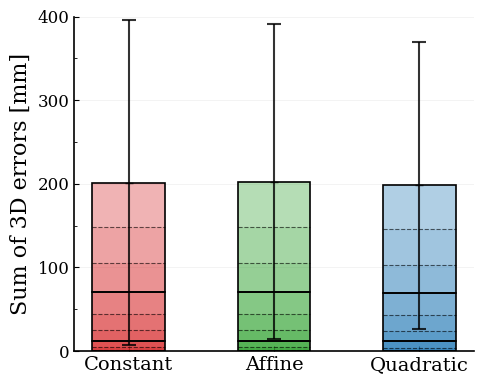

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# === PLOT (SAME style, just 9 segments) ===
colors = {"quad":"tab:blue", "affine":"tab:green", "const":"tab:red"}
models = ["const", "affine", "quad"]
model_labels = ["Constant", "Affine", "Quadratic"]

fig, ax = plt.subplots(figsize=(5, 4))
x_pos = np.arange(len(models))
bar_width = 0.5
alpha_levels = np.linspace(0.95, 0.35, 9)  # 9 layers

for i, m in enumerate(models):
    seg = [overall_means[m][label] for label in contrib_labels]
    total_height = sum(seg)
    std_dev = overall_stds[m]
    bottom = 0.0
    heights = []  # track individual segment heights for grouping
    for j, val in enumerate(seg):
        ax.bar(x_pos[i], val, bar_width, bottom=bottom,
               color=colors[m], alpha=float(alpha_levels[j]))
        heights.append(val)
        bottom += val

    # Add solid black contours every 3 segments
    group_bottom = 0.0
    for g in range(0, 9, 3):
        group_height = sum(heights[g:g+3])
        rect = Rectangle((x_pos[i] - bar_width/2, group_bottom),
                         bar_width, group_height,
                         linewidth=1.2, edgecolor='black', facecolor='none')
        ax.add_patch(rect)
        group_bottom += group_height

    # Add dashed lines between internal segment boundaries
    cum_height = 0.0
    for j in range(8):  # 8 boundaries between 9 segments
        cum_height += heights[j]
        if (j + 1) % 3 != 0:  # skip group boundaries at 3, 6
            ax.hlines(cum_height, x_pos[i] - bar_width/2, x_pos[i] + bar_width/2,
                      colors='black', linestyles='dashed', linewidth=0.8, alpha=0.6)

    # Add error bar
    ax.errorbar(x_pos[i], total_height, yerr=std_dev,
                fmt='k_', capsize=5, capthick=1.5, lw=1.5, alpha=0.8)

ax.set_ylabel("Sum of 3D errors [mm]", fontsize=16)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_labels, fontsize=14)
ax.yaxis.set_major_locator(plt.MultipleLocator(100))
ax.yaxis.set_minor_locator(plt.MultipleLocator(50))
ax.grid(True, axis='y', which='major', linestyle='-', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# <<< fixed y-axis upper limit here >>>
ax.set_ylim(0, 400)

plt.tight_layout()
plt.show()


## ⏰ Testing Forward Kinematics

ANN Kinematics

In [26]:
# Load the TorchScript model
model_pretrained = torch.jit.load("models/kinematics/FK_model.pt", map_location=device)
model_pretrained.eval()

all_preds_pretrained = []
all_labels = []

with torch.no_grad():
    for deltal, pose in tqdm(test_loader_FK, desc="Evaluating"):
        deltal = deltal.to(device)
        pose = pose.to(device)

        preds_pretrained = model_pretrained(deltal)
        
        all_preds_pretrained.append(preds_pretrained.cpu().numpy())
        all_labels.append(pose.cpu().numpy())

        del deltal, pose, preds_pretrained

# Stack all predictions and labels
all_preds_pretrained = np.concatenate(all_preds_pretrained, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Predictions shape: {all_preds_pretrained.shape}")
print(f"Labels shape: {all_labels.shape}")

# Determine number of sections
num_sections = all_preds_pretrained.shape[1] // 6

# Convert angular part to degrees (indices 3, 4, 5 for each section)
angle_indices = []
for section in range(num_sections):
    angle_indices.extend([section*6 + 3, section*6 + 4, section*6 + 5])
angle_indices = np.array(angle_indices)

all_preds_pretrained[:, angle_indices] = np.rad2deg(all_preds_pretrained[:, angle_indices])
all_labels[:, angle_indices] = np.rad2deg(all_labels[:, angle_indices])

# Parameter names with subscripts
base_names = ['X', 'Y', 'Z', 'Yaw', 'Pitch', 'Roll']
units = ['mm', 'mm', 'mm', '°', '°', '°']

# Calculate statistics
mae_values = []
std_values = []

for i in range(all_preds_pretrained.shape[1]):
    # Use AngError for individual angles
    if i % 6 >= 3:  # Angular parameters
        errors = np.array([AngError(all_preds_pretrained[j, i], all_labels[j, i]) 
                          for j in range(len(all_preds_pretrained))])
        mae = np.mean(errors)
        std = np.std(errors)
    else:  # Position parameters
        mae = np.mean(np.abs(all_preds_pretrained[:, i] - all_labels[:, i]))
        std = np.std(np.abs(all_preds_pretrained[:, i] - all_labels[:, i]))
    
    mae_values.append(mae)
    std_values.append(std)

# Section-wise evaluation
import pandas as pd

for section in range(num_sections):
    section_start = section * 6
    section_end = section_start + 6
    
    # Parameter names with proper subscripts
    subscripts = ['₁', '₂', '₃']
    param_names = []
    for name, unit in zip(base_names, units):
        if name == 'X':
            param_name = f'X{subscripts[section]} [{unit}]'
        elif name == 'Y':
            param_name = f'Y{subscripts[section]} [{unit}]'
        elif name == 'Z':
            param_name = f'Z{subscripts[section]} [{unit}]'
        elif name == 'Yaw':
            param_name = f'Yaw{subscripts[section]} [{unit}]'
        elif name == 'Pitch':
            param_name = f'Pitch{subscripts[section]} [{unit}]'
        elif name == 'Roll':
            param_name = f'Roll{subscripts[section]} [{unit}]'
        param_names.append(param_name)
    
    # Create statistics table for this section
    section_mae = mae_values[section_start:section_end]
    section_std = std_values[section_start:section_end]
    
    stats_data = {
        'Parameter': param_names,
        'MAE': [f"{mae:.2f}" for mae in section_mae],
        'Std': [f"{std:.2f}" for std in section_std]
    }
    stats_df = pd.DataFrame(stats_data)
    
    print("=" * 50)
    print(f"SECTION {section+1} EVALUATION RESULTS")
    print("=" * 50)
    
    print("\n--- Parameter-wise Error Statistics ---")
    print(stats_df.to_string(index=False))
    
    # Pose-level errors for this section
    pos_idx = [section_start, section_start+1, section_start+2]
    rot_idx = [section_start+3, section_start+4, section_start+5]
    
    pos_errors = np.linalg.norm(all_preds_pretrained[:,pos_idx] - all_labels[:,pos_idx], axis=1)
    rot_errors = np.array([AngularDistance(np.deg2rad(all_preds_pretrained[i, rot_idx]), 
                                           np.deg2rad(all_labels[i, rot_idx])) 
                          for i in range(len(all_preds_pretrained))]) * 180/np.pi
    
    pos_err_mean = np.mean(pos_errors)
    pos_err_std = np.std(pos_errors)
    rot_err_mean = np.mean(rot_errors)
    rot_err_std = np.std(rot_errors)
    
    pose_stats_data = {
        'Error Type': ['Position [mm]', 'Rotation [°]'],
        'MAE': [f"{pos_err_mean:.2f}", f"{rot_err_mean:.2f}"],
        'Std': [f"{pos_err_std:.2f}", f"{rot_err_std:.2f}"]
    }
    pose_stats_df = pd.DataFrame(pose_stats_data)
    
    print("\n--- Pose-Level Error Summary ---")
    print(pose_stats_df.to_string(index=False))


Evaluating: 100%|██████████| 8/8 [00:00<00:00, 23.31it/s]

Predictions shape: (500, 6)
Labels shape: (500, 6)
SECTION 1 EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
 Parameter   MAE   Std
   X₁ [mm] 13.05 12.22
   Y₁ [mm] 14.50 12.04
   Z₁ [mm]  6.47  5.65
  Yaw₁ [°]  2.64  3.30
Pitch₁ [°]  3.96  3.10
 Roll₁ [°]  5.47  4.91

--- Pose-Level Error Summary ---
   Error Type   MAE   Std
Position [mm] 22.97 14.86
 Rotation [°]  7.25  3.88


In [27]:
# Load both models
fk_model = torch.jit.load("models/kinematics/FK_model.pt", map_location=device)
ik_model = torch.jit.load("models/kinematics/IK_model.pt", map_location=device)
fk_model.eval()
ik_model.eval()

all_preds_ik = []
all_preds_fk_from_ik = []
all_labels = []

with torch.no_grad():
    for deltal, pose in tqdm(test_loader_FK, desc="Evaluating IK->FK"):
        deltal = deltal.to(device)
        pose = pose.to(device)

        # IK: pose -> predicted joint angles
        pred_deltal = ik_model(pose)
        
        # FK: predicted joint angles -> predicted pose
        pred_pose = fk_model(pred_deltal)
        
        all_preds_ik.append(pred_deltal.cpu().numpy())
        all_preds_fk_from_ik.append(pred_pose.cpu().numpy())
        all_labels.append(pose.cpu().numpy())

        del deltal, pose, pred_deltal, pred_pose

# Stack all predictions and labels
all_preds_ik = np.concatenate(all_preds_ik, axis=0)
all_preds_fk_from_ik = np.concatenate(all_preds_fk_from_ik, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"IK predictions shape: {all_preds_ik.shape}")
print(f"FK from IK predictions shape: {all_preds_fk_from_ik.shape}")
print(f"Labels shape: {all_labels.shape}")

# Determine number of sections
num_sections = all_preds_fk_from_ik.shape[1] // 6

# Convert angular part to degrees (indices 3, 4, 5 for each section)
angle_indices = []
for section in range(num_sections):
    angle_indices.extend([section*6 + 3, section*6 + 4, section*6 + 5])
angle_indices = np.array(angle_indices)

all_preds_fk_from_ik[:, angle_indices] = np.rad2deg(all_preds_fk_from_ik[:, angle_indices])
all_labels[:, angle_indices] = np.rad2deg(all_labels[:, angle_indices])

# Parameter names with subscripts
base_names = ['X', 'Y', 'Z', 'Yaw', 'Pitch', 'Roll']
units = ['mm', 'mm', 'mm', '°', '°', '°']

# Calculate statistics
mae_values = []
std_values = []

for i in range(all_preds_fk_from_ik.shape[1]):
    if i % 6 >= 3:  # Angular parameters
        errors = np.array([AngError(all_preds_fk_from_ik[j, i], all_labels[j, i]) 
                          for j in range(len(all_preds_fk_from_ik))])
        mae = np.mean(errors)
        std = np.std(errors)
    else:  # Position parameters
        mae = np.mean(np.abs(all_preds_fk_from_ik[:, i] - all_labels[:, i]))
        std = np.std(np.abs(all_preds_fk_from_ik[:, i] - all_labels[:, i]))
    
    mae_values.append(mae)
    std_values.append(std)

# Section-wise evaluation
import pandas as pd

for section in range(num_sections):
    section_start = section * 6
    section_end = section_start + 6
    
    # Parameter names with subscripts
    subscripts = ['₁', '₂', '₃']
    param_names = []
    for name, unit in zip(base_names, units):
        if name == 'X':
            param_name = f'X{subscripts[section]} [{unit}]'
        elif name == 'Y':
            param_name = f'Y{subscripts[section]} [{unit}]'
        elif name == 'Z':
            param_name = f'Z{subscripts[section]} [{unit}]'
        elif name == 'Yaw':
            param_name = f'Yaw{subscripts[section]} [{unit}]'
        elif name == 'Pitch':
            param_name = f'Pitch{subscripts[section]} [{unit}]'
        elif name == 'Roll':
            param_name = f'Roll{subscripts[section]} [{unit}]'
        param_names.append(param_name)
    
    # Stats for this section
    section_mae = mae_values[section_start:section_end]
    section_std = std_values[section_start:section_end]
    
    stats_data = {
        'Parameter': param_names,
        'MAE': [f"{mae:.2f}" for mae in section_mae],
        'Std': [f"{std:.2f}" for std in section_std]
    }
    stats_df = pd.DataFrame(stats_data)
    
    print("=" * 50)
    print(f"SECTION {section+1} IK→FK EVALUATION RESULTS")
    print("=" * 50)
    
    print("\n--- Parameter-wise Error Statistics ---")
    print(stats_df.to_string(index=False))
    
    # Pose-level errors for this section
    pos_idx = [section_start, section_start+1, section_start+2]
    rot_idx = [section_start+3, section_start+4, section_start+5]
    
    pos_errors = np.linalg.norm(all_preds_fk_from_ik[:,pos_idx] - all_labels[:,pos_idx], axis=1)
    rot_errors = np.array([AngularDistance(np.deg2rad(all_preds_fk_from_ik[i, rot_idx]), 
                                           np.deg2rad(all_labels[i, rot_idx])) 
                          for i in range(len(all_preds_fk_from_ik))]) * 180/np.pi
    
    pos_err_mean = np.mean(pos_errors)
    pos_err_std = np.std(pos_errors)
    rot_err_mean = np.mean(rot_errors)
    rot_err_std = np.std(rot_errors)
    
    pose_stats_data = {
        'Error Type': ['Position [mm]', 'Rotation [°]'],
        'MAE': [f"{pos_err_mean:.2f}", f"{rot_err_mean:.2f}"],
        'Std': [f"{pos_err_std:.2f}", f"{rot_err_std:.2f}"]
    }
    pose_stats_df = pd.DataFrame(pose_stats_data)
    
    print("\n--- Pose-Level Error Summary ---")
    print(pose_stats_df.to_string(index=False))


Evaluating IK->FK: 100%|██████████| 8/8 [00:00<00:00, 78.83it/s]

IK predictions shape: (500, 9)
FK from IK predictions shape: (500, 6)
Labels shape: (500, 6)
SECTION 1 IK→FK EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
 Parameter  MAE  Std
   X₁ [mm] 4.55 3.75
   Y₁ [mm] 4.87 3.86
   Z₁ [mm] 5.12 4.09
  Yaw₁ [°] 1.59 1.59
Pitch₁ [°] 7.24 5.65
 Roll₁ [°] 2.76 2.41

--- Pose-Level Error Summary ---
   Error Type  MAE  Std
Position [mm] 9.43 5.23
 Rotation [°] 8.33 5.42


PCC Forward Kinematics

In [28]:
# Use PCC model
all_labels = []
all_PCC_xyz = []

# Initial conditions (rest position)
DELTAL0 = np.full(9, 1e-4)
DxDyDl0 = np.full(9, 1e-4)
coords0 = np.array([0, 0, 145 * 3, 1e-4, 1e-4, 1e-4])
xyz0 = np.array([0, 0, 145, 0, 0, 145 * 2, 0, 0, 145 * 3])

with torch.no_grad():
    for deltal, pose in tqdm(test_loader_FK, desc="Evaluating"):
        deltal = deltal.to(device)
        pose = pose.to(device)

        # Process each sample in the batch for PCC calculation
        batch_PCC = []
        deltal_np = deltal.cpu().numpy()
        
        for i in range(deltal_np.shape[0]):
            _, _, PCC_xyz = tendon2coordinates(DELTAL0, DxDyDl0, coords0, deltal_np[i] - DELTAL0)
            batch_PCC.append(PCC_xyz)
        
        batch_PCC = np.array(batch_PCC)
        
        all_labels.append(pose.cpu().numpy())
        all_PCC_xyz.append(batch_PCC)

        del deltal, pose, batch_PCC

# Stack all predictions and labels
all_labels = np.concatenate(all_labels, axis=0)
all_PCC_xyz = np.concatenate(all_PCC_xyz, axis=0)

print(f"Labels shape: {all_labels.shape}")
print(f"PCC shape: {all_PCC_xyz.shape}")

# Determine number of sections
num_sections = all_PCC_xyz.shape[1] // 6

# Convert angular part to degrees (indices 3, 4, 5 for each section)
angle_indices = []
for section in range(num_sections):
    angle_indices.extend([section*6 + 3, section*6 + 4, section*6 + 5])
angle_indices = np.array(angle_indices)

all_labels[:, angle_indices] = np.rad2deg(all_labels[:, angle_indices])
all_PCC_xyz[:, angle_indices] = np.rad2deg(all_PCC_xyz[:, angle_indices])

# Parameter names with subscripts
base_names = ['X', 'Y', 'Z', 'Yaw', 'Pitch', 'Roll']
units = ['mm', 'mm', 'mm', '°', '°', '°']

# Calculate statistics
mae_values = []
std_values = []

for i in range(all_PCC_xyz.shape[1]):
    mae = np.mean(np.abs(all_PCC_xyz[:, i] - all_labels[:, i]))
    std = np.std(np.abs(all_PCC_xyz[:, i] - all_labels[:, i]))
    mae_values.append(mae)
    std_values.append(std)

# Section-wise evaluation (no plots)
import pandas as pd

for section in range(num_sections):
    section_start = section * 6
    section_end = section_start + 6
    
    # Parameter names with subscripts
    subscripts = ['₁', '₂', '₃']
    param_names = []
    for name, unit in zip(base_names, units):
        if name == 'X':
            param_name = f'X{subscripts[section]} [{unit}]'
        elif name == 'Y':
            param_name = f'Y{subscripts[section]} [{unit}]'
        elif name == 'Z':
            param_name = f'Z{subscripts[section]} [{unit}]'
        elif name == 'Yaw':
            param_name = f'Yaw{subscripts[section]} [{unit}]'
        elif name == 'Pitch':
            param_name = f'Pitch{subscripts[section]} [{unit}]'
        elif name == 'Roll':
            param_name = f'Roll{subscripts[section]} [{unit}]'
        param_names.append(param_name)
    
    # Create statistics table for this section
    section_mae = mae_values[section_start:section_end]
    section_std = std_values[section_start:section_end]
    
    stats_data = {
        'Parameter': param_names,
        'MAE': [f"{mae:.2f}" for mae in section_mae],
        'Std': [f"{std:.2f}" for std in section_std]
    }
    stats_df = pd.DataFrame(stats_data)
    
    print("=" * 50)
    print(f"SECTION {section+1} PCC EVALUATION RESULTS")
    print("=" * 50)
    
    print("\n--- Parameter-wise Error Statistics ---")
    print(stats_df.to_string(index=False))
    
    # Pose-level errors for this section
    pos_idx = [section_start, section_start+1, section_start+2]
    rot_idx = [section_start+3, section_start+4, section_start+5]
    
    pos_errors = np.linalg.norm(all_PCC_xyz[:, pos_idx] - all_labels[:, pos_idx], axis=1)
    rot_errors = np.array([
        AngularDistance(np.deg2rad(all_PCC_xyz[i, rot_idx]), np.deg2rad(all_labels[i, rot_idx]))
        for i in range(len(all_PCC_xyz))
    ]) * 180/np.pi
    
    pos_err_mean = np.mean(pos_errors)
    pos_err_std = np.std(pos_errors)
    rot_err_mean = np.mean(rot_errors)
    rot_err_std = np.std(rot_errors)
    
    pose_stats_data = {
        'Error Type': ['Position [mm]', 'Rotation [°]'],
        'MAE': [f"{pos_err_mean:.2f}", f"{rot_err_mean:.2f}"],
        'Std': [f"{pos_err_std:.2f}", f"{rot_err_std:.2f}"]
    }
    pose_stats_df = pd.DataFrame(pose_stats_data)
    print("\n--- Pose-Level Error Summary ---")
    print(pose_stats_df.to_string(index=False))


Evaluating: 100%|██████████| 8/8 [19:13<00:00, 144.23s/it]

Labels shape: (500, 6)
PCC shape: (500, 6)
SECTION 1 PCC EVALUATION RESULTS

--- Parameter-wise Error Statistics ---
 Parameter   MAE   Std
   X₁ [mm] 23.71 19.53
   Y₁ [mm] 24.18 22.94
   Z₁ [mm] 12.65 11.08
  Yaw₁ [°] 13.32 20.63
Pitch₁ [°]  6.47  5.68
 Roll₁ [°] 10.42 12.28

--- Pose-Level Error Summary ---
   Error Type   MAE   Std
Position [mm] 40.14 26.94
 Rotation [°] 21.47 23.05


## ⏰ Curvature Checks

In [24]:
# Upload data
data = np.load("CurvatureDataCheck.npz")

# Mocap and ANN parameters split
s_quad_mocap, c0_quad_mocap, c1_quad_mocap, c2_quad_mocap, phi_quad_mocap = np.hsplit(data["quad_mocap"], 5)
s_aff_mocap, c0_aff_mocap, c1_aff_mocap, phi_aff_mocap = np.hsplit(data["aff_mocap"], 4)
s_const_mocap, c0_const_mocap, phi_const_mocap = np.hsplit(data["const_mocap"], 3)
s_quad_ann, c0_quad_ann, c1_quad_ann, c2_quad_ann, phi_quad_ann = np.hsplit(data["quad_ANN"], 5)
s_aff_ann, c0_aff_ann, c1_aff_ann, phi_aff_ann = np.hsplit(data["aff_ANN"], 4)
s_const_ann, c0_const_ann, phi_const_ann = np.hsplit(data["const_ANN"], 3)

# Number of samples
N = data["quad_mocap"].shape[0]

# Labels for 9-point analysis
contrib_labels = [
    "S1/3", "2S1/3", "S1",
    "S1+S2/3", "S1+2S2/3", "S1+S2",
    "S1+S2+S3/3", "S1+S2+2S3/3", "S1+S2+S3"
]

errors_by_fraction = {
    "quad":   {label: [] for label in contrib_labels},
    "affine": {label: [] for label in contrib_labels},
    "const":  {label: [] for label in contrib_labels},
}
errors_by_model = {"quad": [], "affine": [], "const": []}

# Loop over samples
for i in range(N):
    models_data = {
        "quad": {
            "gt_params": (
                float(s_quad_mocap[i,0]), float(c0_quad_mocap[i,0]), float(c1_quad_mocap[i,0]), float(c2_quad_mocap[i,0]), float(phi_quad_mocap[i,0]),
                float(s_quad_mocap[i,1]), float(c0_quad_mocap[i,1]), float(c1_quad_mocap[i,1]), float(c2_quad_mocap[i,1]), float(phi_quad_mocap[i,1]),
                float(s_quad_mocap[i,2]), float(c0_quad_mocap[i,2]), float(c1_quad_mocap[i,2]), float(c2_quad_mocap[i,2]), float(phi_quad_mocap[i,2])
            ),
            "pred_params": (
                float(s_quad_ann[i,0]), float(c0_quad_ann[i,0]), float(c1_quad_ann[i,0]), float(c2_quad_ann[i,0]), float(phi_quad_ann[i,0]),
                float(s_quad_ann[i,1]), float(c0_quad_ann[i,1]), float(c1_quad_ann[i,1]), float(c2_quad_ann[i,1]), float(phi_quad_ann[i,1]),
                float(s_quad_ann[i,2]), float(c0_quad_ann[i,2]), float(c1_quad_ann[i,2]), float(c2_quad_ann[i,2]), float(phi_quad_ann[i,2])
            ),
        },
        "affine": {
            "gt_params": (
                float(s_aff_mocap[i,0]), float(c0_aff_mocap[i,0]), float(c1_aff_mocap[i,0]), 0.0, float(phi_aff_mocap[i,0]),
                float(s_aff_mocap[i,1]), float(c0_aff_mocap[i,1]), float(c1_aff_mocap[i,1]), 0.0, float(phi_aff_mocap[i,1]),
                float(s_aff_mocap[i,2]), float(c0_aff_mocap[i,2]), float(c1_aff_mocap[i,2]), 0.0, float(phi_aff_mocap[i,2])
            ),
            "pred_params": (
                float(s_aff_ann[i,0]), float(c0_aff_ann[i,0]), float(c1_aff_ann[i,0]), 0.0, float(phi_aff_ann[i,0]),
                float(s_aff_ann[i,1]), float(c0_aff_ann[i,1]), float(c1_aff_ann[i,1]), 0.0, float(phi_aff_ann[i,1]),
                float(s_aff_ann[i,2]), float(c0_aff_ann[i,2]), float(c1_aff_ann[i,2]), 0.0, float(phi_aff_ann[i,2])
            ),
        },
        "const": {
            "gt_params": (
                float(s_const_mocap[i,0]), float(c0_const_mocap[i,0]), 0.0, 0.0, float(phi_const_mocap[i,0]),
                float(s_const_mocap[i,1]), float(c0_const_mocap[i,1]), 0.0, 0.0, float(phi_const_mocap[i,1]),
                float(s_const_mocap[i,2]), float(c0_const_mocap[i,2]), 0.0, 0.0, float(phi_const_mocap[i,2])
            ),
            "pred_params": (
                float(s_const_ann[i,0]), float(c0_const_ann[i,0]), 0.0, 0.0, float(phi_const_ann[i,0]),
                float(s_const_ann[i,1]), float(c0_const_ann[i,1]), 0.0, 0.0, float(phi_const_ann[i,1]),
                float(s_const_ann[i,2]), float(c0_const_ann[i,2]), 0.0, 0.0, float(phi_const_ann[i,2])
            ),
        }
    }

    # Compute errors
    for model_name, params in models_data.items():
        points_gt = np.array(get_points_at_fractions(*params["gt_params"]))     # shape (9, 3)
        points_pred = np.array(get_points_at_fractions(*params["pred_params"])) # shape (9, 3)
        diffs = np.linalg.norm(points_pred - points_gt, axis=1)                 # shape (9,)

        # Accumulate
        for j, label in enumerate(contrib_labels):
            errors_by_fraction[model_name][label].append(diffs[j])
        errors_by_model[model_name].append(diffs.sum())

# Aggregate
overall_means = {
    m: {label: float(np.mean(errors_by_fraction[m][label])) for label in contrib_labels}
    for m in ["quad", "affine", "const"]
}
overall_stds = {
    m: float(np.std(errors_by_model[m], ddof=1)) for m in ["quad", "affine", "const"]
}

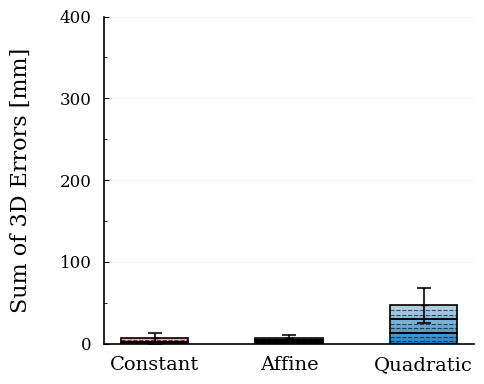

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# === Plot parameters ===
colors = {"quad": "tab:blue", "affine": "tab:green", "const": "tab:red"}
models = ["const", "affine", "quad"]
model_labels = ["Constant", "Affine", "Quadratic"]

fig, ax = plt.subplots(figsize=(5, 4))
x_pos = np.arange(len(models))
bar_width = 0.5
alpha_levels = np.linspace(0.95, 0.35, 9)  # 9 layers for 9 segments

for i, m in enumerate(models):
    seg = [overall_means[m][label] for label in contrib_labels]
    total_height = sum(seg)
    std_dev = overall_stds[m]
    bottom = 0.0
    heights = []

    for j, val in enumerate(seg):
        ax.bar(x_pos[i], val, bar_width, bottom=bottom,
               color=colors[m], alpha=float(alpha_levels[j]))
        heights.append(val)
        bottom += val

    # Solid group contours (every 3 segments)
    group_bottom = 0.0
    for g in range(0, 9, 3):
        group_height = sum(heights[g:g+3])
        rect = Rectangle((x_pos[i] - bar_width / 2, group_bottom),
                         bar_width, group_height,
                         linewidth=1.2, edgecolor='black', facecolor='none')
        ax.add_patch(rect)
        group_bottom += group_height

    # Dashed lines for internal segment boundaries
    cum_height = 0.0
    for j in range(8):
        cum_height += heights[j]
        if (j + 1) % 3 != 0:  # not on major section boundaries
            ax.hlines(cum_height, x_pos[i] - bar_width / 2, x_pos[i] + bar_width / 2,
                      colors='black', linestyles='dashed', linewidth=0.8, alpha=0.6)

    # Error bar for total standard deviation
    ax.errorbar(x_pos[i], total_height, yerr=std_dev,
                fmt='k_', capsize=5, capthick=1.5, lw=1.5, alpha=0.8)

# === Aesthetics ===
ax.set_ylabel("Sum of 3D Errors [mm]", fontsize=16, labelpad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_labels, fontsize=14)
ax.tick_params(axis='both', which='major', pad=9)

ax.yaxis.set_major_locator(plt.MultipleLocator(100))
ax.yaxis.set_minor_locator(plt.MultipleLocator(50))
ax.grid(True, axis='y', which='major', linestyle='-', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# <<< fixed upper limit here >>>
ax.set_ylim(0, 400)

plt.tight_layout()
plt.show()
